In [1]:
# ============================================================
# CELL 1-A: Standard Library, Sklearn, Optuna, Imbalanced-Learn
# ============================================================
import random
import warnings

# Reproducibility seeds — set FIRST before any random ops
random.seed(42)

try:
    import numpy as np
    np.random.seed(42)
    print(f"numpy          {np.__version__}")
except ImportError as e:
    print(f"[ERROR] numpy: {e}")

try:
    import pandas as pd
    pd.set_option('display.max_columns', 50)
    print(f"pandas         {pd.__version__}")
except ImportError as e:
    print(f"[ERROR] pandas: {e}")

try:
    import matplotlib.pyplot as plt
    import seaborn as sns
    sns.set_style('whitegrid')
    # NOTE: no global plt.rcParams override — figsize set per plot
    print(f"matplotlib     {plt.matplotlib.__version__}")
    print(f"seaborn        {sns.__version__}")
except ImportError as e:
    print(f"[ERROR] matplotlib/seaborn: {e}")

try:
    import sklearn
    from sklearn.impute import SimpleImputer
    from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
    from sklearn.pipeline import Pipeline
    from sklearn.compose import ColumnTransformer
    from sklearn.feature_selection import (
        VarianceThreshold, mutual_info_classif,
        RFE, SelectKBest
    )
    from sklearn.ensemble import (
        RandomForestClassifier, GradientBoostingClassifier,
        IsolationForest
    )
    from sklearn.linear_model import LogisticRegression
    from sklearn.svm import SVC
    from sklearn.decomposition import PCA, TruncatedSVD
    from sklearn.manifold import TSNE
    from sklearn.model_selection import (
        train_test_split, StratifiedKFold,
        cross_val_score, GridSearchCV
    )
    from sklearn.metrics import (
        classification_report, confusion_matrix,
        precision_score, recall_score, f1_score,
        roc_auc_score, roc_curve,
        average_precision_score, matthews_corrcoef
    )
    from sklearn.metrics.pairwise import euclidean_distances
    print(f"scikit-learn   {sklearn.__version__}")
except ImportError as e:
    print(f"[ERROR] scikit-learn: {e}")

try:
    import imblearn
    from imblearn.over_sampling import SMOTE, ADASYN
    from imblearn.combine import SMOTETomek
    from imblearn.pipeline import Pipeline as ImbPipeline
    print(f"imbalanced-learn {imblearn.__version__}")
except ImportError as e:
    print(f"[ERROR] imbalanced-learn: {e}")

try:
    import optuna
    from optuna.samplers import TPESampler
    print(f"optuna         {optuna.__version__}")
except ImportError as e:
    print(f"[ERROR] optuna: {e}")

try:
    from scipy import stats
    from scipy.cluster.hierarchy import dendrogram, linkage
    from scipy.stats import mannwhitneyu
    import scipy
    print(f"scipy          {scipy.__version__}")
except ImportError as e:
    print(f"[ERROR] scipy: {e}")

warnings.filterwarnings('ignore')
print("\n[OK] Cell 1-A complete — standard library + sklearn loaded.")


numpy          2.4.6
pandas         3.0.3
matplotlib     3.11.0
seaborn        0.13.2
scikit-learn   1.9.0
imbalanced-learn 0.14.2
optuna         4.9.0
scipy          1.17.1

[OK] Cell 1-A complete — standard library + sklearn loaded.


In [2]:
# ============================================================
# CELL 1-B: Gradient Boosting Libraries
# ============================================================
try:
    import xgboost as xgb
    from xgboost import XGBClassifier
    print(f"xgboost        {xgb.__version__}")
except ImportError as e:
    print(f"[ERROR] xgboost: {e}")

try:
    import lightgbm as lgb
    from lightgbm import LGBMClassifier
    print(f"lightgbm       {lgb.__version__}")
except ImportError as e:
    print(f"[ERROR] lightgbm: {e}")

try:
    import catboost
    from catboost import CatBoostClassifier
    print(f"catboost       {catboost.__version__}")
except ImportError as e:
    print(f"[ERROR] catboost: {e}")

print("\n[OK] Cell 1-B complete — GBDT libraries loaded.")


xgboost        3.2.0
lightgbm       4.6.0
catboost       1.2.10

[OK] Cell 1-B complete — GBDT libraries loaded.


In [3]:
# ============================================================
# CELL 1-C: Dimensionality Reduction & Explainability
# ============================================================
try:
    import umap
    print(f"umap-learn     {umap.__version__}")
except ImportError as e:
    print(f"[ERROR] umap-learn: {e}")

try:
    import shap
    print(f"shap           {shap.__version__}")
except ImportError as e:
    print(f"[ERROR] shap: {e}")

print("\n[OK] Cell 1-C complete — UMAP + SHAP loaded.")


umap-learn     0.5.12
shap           0.52.0

[OK] Cell 1-C complete — UMAP + SHAP loaded.


In [5]:

df = pd.read_csv('DataSet.csv')
print(f"Data loaded: {df.shape[0]:,} rows, {df.shape[1]:,} columns")

# Drop identifier column if exists
if 'Unnamed: 0' in df.columns:
    df = df.drop('Unnamed: 0', axis=1)
    print("Dropped 'Unnamed: 0' column")

# ── DECISION GATE 1: Assert target column exists ──────────────────────────────
assert 'F3924' in df.columns, (
    "Target column 'F3924' is missing from the dataset. "
    "Check that the correct CSV was loaded and the column was not dropped."
)

# Separate features and target
target_col = 'F3924'
X = df.drop(columns=[target_col])
y = df[target_col]

print(f"\nDataset Info:")
print(f"  Shape         : {df.shape[0]:,} rows x {df.shape[1]:,} columns")
print(f"  Features      : {X.shape[1]:,}")

# ── DECISION GATE 2: Class balance as percentages ─────────────────────────────
print("\nClass Balance (%):")
print(y.value_counts(normalize=True).mul(100).round(2).to_string())
print(f"  Imbalance ratio: {len(y[y==0])/len(y[y==1]):.1f}:1")

# ── DECISION GATE 3: Data type distribution ───────────────────────────────────
print("\nData Type Distribution (Decision Gate):")
print(df.dtypes.value_counts().to_string())

# ── DECISION GATE 4: Columns with >80% missing ────────────────────────────────
missing_pct = df.isnull().mean() * 100
n_above_80 = int((missing_pct > 80).sum())
print(f"\nColumns with >80% missing values : {n_above_80:,}")
print("  -> If high (>500), consider raising missing_threshold in clean_dataset()")


Data loaded: 9,082 rows, 3,925 columns
Dropped 'Unnamed: 0' column

Dataset Info:
  Shape         : 9,082 rows x 3,924 columns
  Features      : 3,923

Class Balance (%):
F3924
0    99.11
1     0.89
  Imbalance ratio: 111.1:1

Data Type Distribution (Decision Gate):
float64    3876
int64        40
str           8

Columns with >80% missing values : 908
  -> If high (>500), consider raising missing_threshold in clean_dataset()


In [5]:
df.head()

,F1,F2,F3,F4,F5,F6,F7,F8,F9,F10,F11,F12,F13,F14,F15,F16,F17,F18,F19,F20,F21,F22,F23,F24,F25,...,F3900,F3901,F3902,F3903,F3904,F3905,F3906,F3907,F3908,F3909,F3910,F3911,F3912,F3913,F3914,F3915,F3916,F3917,F3918,F3919,F3920,F3921,F3922,F3923,F3924
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.59,0.74,0.38,0.64,0.67,0.63,0.59,0.74,0.38,0.64,0.67,0.63,0.59,...,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,1,0,0,1,0,0
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.80,0.86,0.79,0.95,0.94,0.96,0.80,0.86,0.79,0.95,0.94,0.96,0.80,...,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,0
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.76,0.88,0.67,0.95,0.93,0.98,0.76,0.88,0.67,0.95,0.93,0.98,0.76,...,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,1,0,0,1,0,0
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.46,0.54,0.46,0.94,0.96,0.92,0.46,0.54,0.46,0.94,0.96,0.92,0.46,...,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,1,0,0,1,0,0
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.50,0.64,0.46,0.39,0.43,0.35,0.50,0.64,0.46,0.39,0.43,0.35,0.50,...,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,1,0,1,0,0,0


### Date Cleaning


STEP 1: DATA CLEANING


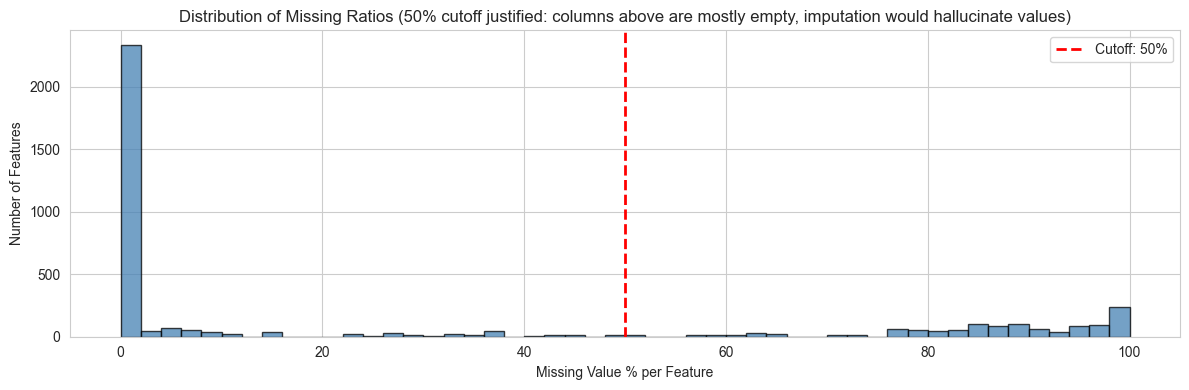

  Missing-ratio plot saved.
  Dropped 1138 columns (>50% missing)

  Cleaning Summary:
  Step                                 Columns
  -------------------------------------------
  Original                               3,923
  After missing drop (>{missing_threshold*100:.0f}%)    2,785  (-1,138)
  After variance threshold ({variance_threshold})    2,012  (-773)
  Final                                  2,012

  Cleaned shape: (9082, 2012)

cleaning_pipeline is unfitted — refit on X_train only in the modeling step.


In [6]:


def clean_dataset(X, y, missing_threshold=0.5, variance_threshold=0.01):
    """
    Data cleaning pipeline.

    Strategy:
    - Column dropping (missing ratio) is data-aware: computed on full X before split,
      because missingness is a structural property of the data, not the split.
    - Imputation and variance thresholding are wrapped in a sklearn Pipeline so they
      can be fitted exclusively on X_train during modeling (avoids leakage).

    Returns:
        X_clean (DataFrame), y (Series), cleaning_pipeline (unfitted Pipeline)
    """
    print("\n" + "="*60)
    print("STEP 1: DATA CLEANING")
    print("="*60)

    n_original = X.shape[1]

    # ── Step 1: Drop columns with too many missing values (data-aware) ─────────
    # Missing ratio is a structural dataset property — safe to compute on all data.
    missing_ratio = X.isnull().mean()

    # Plot missing-ratio distribution with cutoff marker
    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.hist(missing_ratio.values * 100, bins=50, color='steelblue',
            edgecolor='black', alpha=0.75)
    ax.axvline(x=missing_threshold * 100, color='red', linestyle='--', linewidth=2,
               label=f'Cutoff: {missing_threshold*100:.0f}%')
    ax.set_xlabel('Missing Value % per Feature')
    ax.set_ylabel('Number of Features')
    ax.set_title('Distribution of Missing Ratios (50% cutoff justified: '
                 'columns above are mostly empty, imputation would hallucinate values)')
    ax.legend()
    plt.tight_layout()
    plt.savefig('missing_ratio_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  Missing-ratio plot saved.")

    cols_to_drop = missing_ratio[missing_ratio > missing_threshold].index.tolist()
    X_after_missing = X.drop(columns=cols_to_drop)
    n_after_missing = X_after_missing.shape[1]
    print(f"  Dropped {len(cols_to_drop)} columns (>{missing_threshold*100:.0f}% missing)")

    # ── Step 2: Build Pipeline for imputation + variance filtering ─────────────
    # IMPORTANT: This pipeline is returned UNFITTED.
    # It must be fitted only on X_train to prevent leakage.
    from sklearn.pipeline import Pipeline
    from sklearn.impute import SimpleImputer
    from sklearn.feature_selection import VarianceThreshold

    cleaning_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('variance_threshold', VarianceThreshold(threshold=variance_threshold)),
    ])

    # For this cleaning step (pre-split EDA/feature selection), we fit on X_after_missing
    # with a clear comment that in the modeling step this must be fit on X_train only.
    import numpy as np
    numeric_cols = X_after_missing.select_dtypes(include=[np.number]).columns.tolist()
    X_numeric = X_after_missing[numeric_cols]

    X_array = cleaning_pipeline.fit_transform(X_numeric)  # EDA fit — NOT modeling fit

    # Recover feature names after variance filter
    vt = cleaning_pipeline.named_steps['variance_threshold']
    kept_cols = X_numeric.columns[vt.get_support()].tolist()
    X_clean = pd.DataFrame(X_array, columns=kept_cols, index=X_numeric.index)

    n_after_variance = X_clean.shape[1]

    # ── Summary table ──────────────────────────────────────────────────────────
    print("\n  Cleaning Summary:")
    print(f"  {'Step':<35} {'Columns':>8}")
    print(f"  {'-'*43}")
    print(f"  {'Original':35} {n_original:>8,}")
    print(f"  {'After missing drop (>{missing_threshold*100:.0f}%)':35} {n_after_missing:>8,}  (-{n_original - n_after_missing:,})")
    print(f"  {'After variance threshold ({variance_threshold})':35} {n_after_variance:>8,}  (-{n_after_missing - n_after_variance:,})")
    print(f"  {'Final':35} {n_after_variance:>8,}")
    print(f"\n  Cleaned shape: {X_clean.shape}")

    # cleaning_pipeline returned for use in modeling (fit on X_train only there)
    return X_clean, y, cleaning_pipeline


X_clean, y_clean, cleaning_pipeline = clean_dataset(X, y)
print("\ncleaning_pipeline is unfitted — refit on X_train only in the modeling step.")


### EDA


STEP 2: EXPLORATORY DATA ANALYSIS


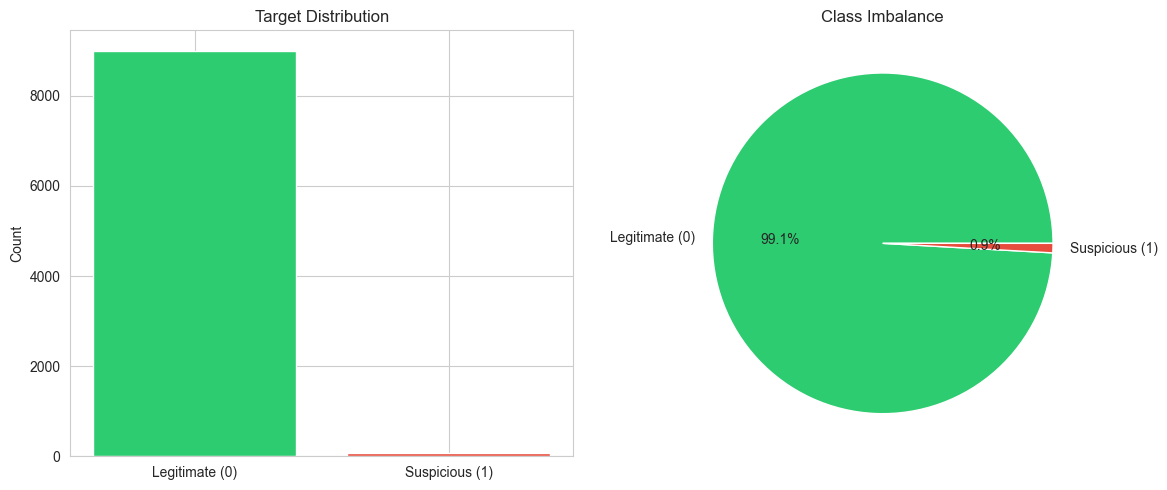


  Analyzing class separability with PCA...


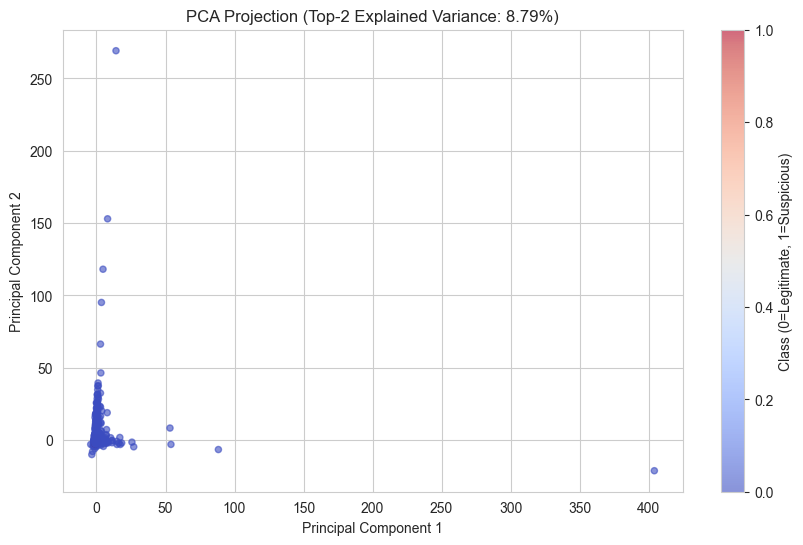

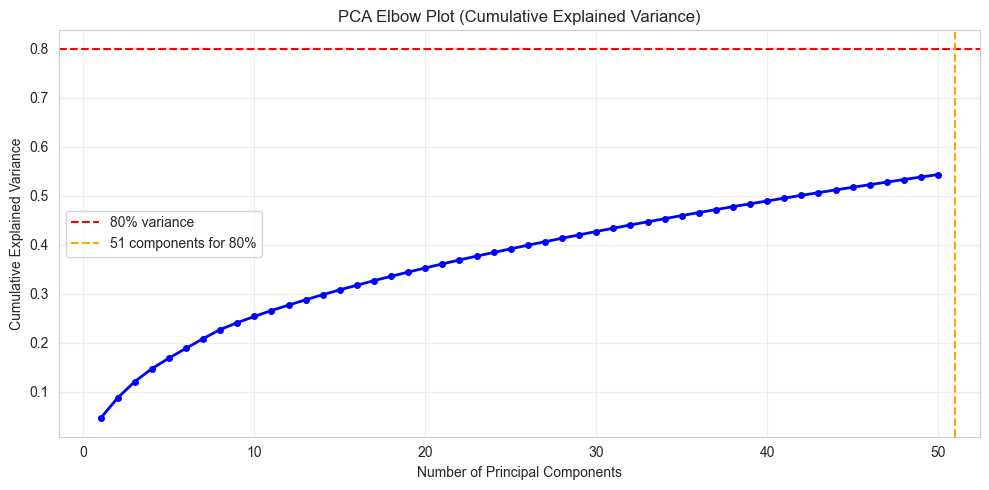

  Components needed to reach 80% variance: 51 / 50

  Running UMAP for non-linear visualization...


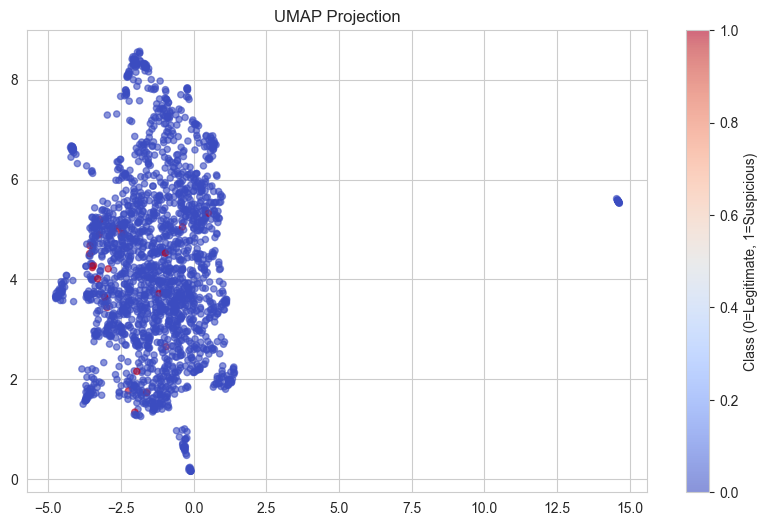


  Ranking features by Mann-Whitney U p-value (most discriminative first)...
  Top 6 most discriminative features (by Mann-Whitney U p-value):
    F3811                 p = 3.06e-24
    F3805                 p = 7.99e-24
    F3799                 p = 5.86e-23
    F1813                 p = 9.57e-23
    F1921                 p = 2.92e-22
    F1705                 p = 4.04e-22


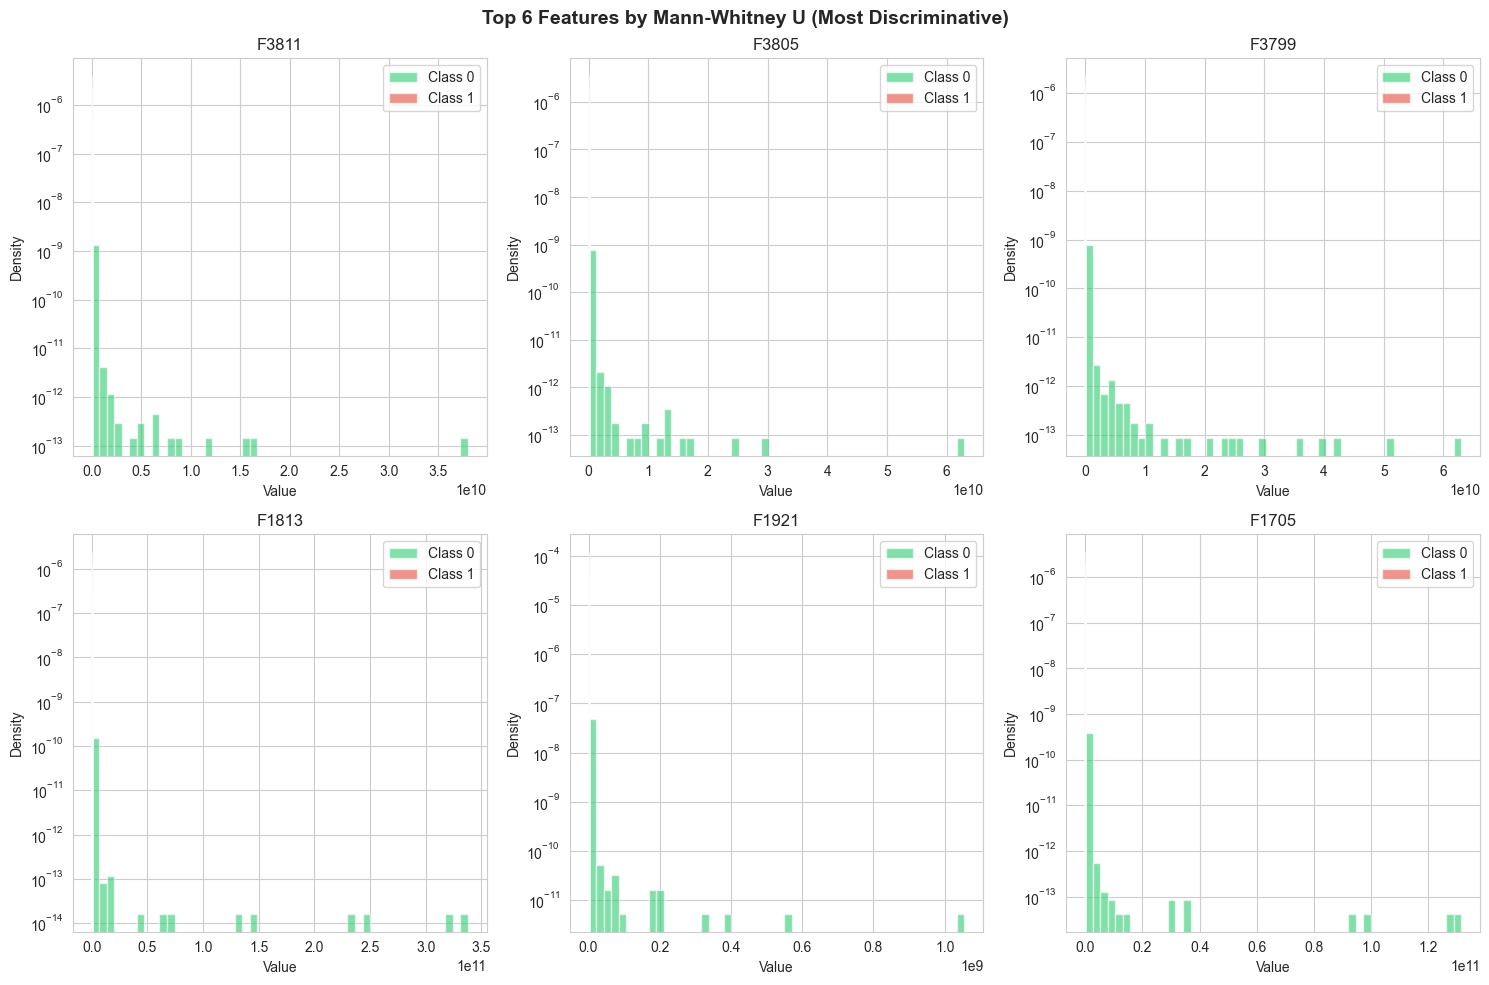


  EDA complete


In [7]:


def perform_eda(X, y, max_samples=2000):
    """
    Comprehensive EDA. Top features selected by Mann-Whitney U p-value
    (most discriminative between classes), not by variance.
    PCA includes elbow plot and low-variance warning.
    StandardScaler here is visualization-only -- NOT the modeling scaler.
    """
    import numpy as np
    import matplotlib.pyplot as plt
    from scipy.stats import mannwhitneyu
    from sklearn.preprocessing import StandardScaler  # visualization-only
    from sklearn.decomposition import PCA
    import umap

    print("\n" + "="*60)
    print("STEP 2: EXPLORATORY DATA ANALYSIS")
    print("="*60)

    # ── 1. Target Distribution ─────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].bar(
        ['Legitimate (0)', 'Suspicious (1)'],
        y.value_counts().sort_index(),
        color=['#2ecc71', '#e74c3c']
    )
    axes[0].set_title('Target Distribution')
    axes[0].set_ylabel('Count')

    axes[1].pie(
        y.value_counts().sort_index(),
        labels=['Legitimate (0)', 'Suspicious (1)'],
        autopct='%1.1f%%',
        colors=['#2ecc71', '#e74c3c']
    )
    axes[1].set_title('Class Imbalance')

    plt.tight_layout()
    plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ── 2. PCA for Class Separability ──────────────────────────────────────────
    print("\n  Analyzing class separability with PCA...")
    sample_size = min(max_samples, len(X))
    X_sample = X.sample(sample_size, random_state=42)
    y_sample = y.loc[X_sample.index]

    # NOTE: This scaler is for visualization only -- NOT used in modeling.
    vis_scaler = StandardScaler()
    X_scaled = vis_scaler.fit_transform(X_sample)

    # 2a. 2-component PCA scatter
    pca2 = PCA(n_components=2)
    X_pca2 = pca2.fit_transform(X_scaled)
    top2_var = pca2.explained_variance_ratio_.sum()

    plt.figure(figsize=(10, 6))
    scatter = plt.scatter(
        X_pca2[:, 0], X_pca2[:, 1],
        c=y_sample, cmap='coolwarm', alpha=0.6, s=20
    )
    plt.colorbar(scatter, label='Class (0=Legitimate, 1=Suspicious)')
    plt.title(f'PCA Projection (Top-2 Explained Variance: {top2_var:.2%})')
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.savefig('pca_visualization.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Warning if PCA scatter is not interpretable
    if top2_var < 0.05:
        print("  WARNING: Top 2 PCs explain <5% variance -- "
              "PCA scatter is not interpretable. "
              "Consider using UMAP or t-SNE instead.")

    # 2b. PCA elbow plot -- cumulative explained variance up to 50 components
    n_elbow = min(50, X_scaled.shape[1], X_scaled.shape[0] - 1)
    pca_elbow = PCA(n_components=n_elbow)
    pca_elbow.fit(X_scaled)
    cumvar = np.cumsum(pca_elbow.explained_variance_ratio_)

    # Find how many components reach 80%
    n_80pct = int(np.searchsorted(cumvar, 0.80)) + 1

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(range(1, n_elbow + 1), cumvar, 'bo-', linewidth=2, markersize=4)
    ax.axhline(y=0.80, color='red', linestyle='--', label='80% variance')
    ax.axvline(x=n_80pct, color='orange', linestyle='--',
               label=f'{n_80pct} components for 80%')
    ax.set_xlabel('Number of Principal Components')
    ax.set_ylabel('Cumulative Explained Variance')
    ax.set_title('PCA Elbow Plot (Cumulative Explained Variance)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('pca_elbow.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f"  Components needed to reach 80% variance: {n_80pct} / {n_elbow}")

    # ── 3. UMAP (if manageable) ────────────────────────────────────────────────
    if len(X) < 10000:
        print("\n  Running UMAP for non-linear visualization...")
        reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15)
        X_umap = reducer.fit_transform(X_scaled)

        plt.figure(figsize=(10, 6))
        plt.scatter(X_umap[:, 0], X_umap[:, 1],
                    c=y_sample, cmap='coolwarm', alpha=0.6, s=20)
        plt.colorbar(label='Class (0=Legitimate, 1=Suspicious)')
        plt.title('UMAP Projection')
        plt.savefig('umap_visualization.png', dpi=150, bbox_inches='tight')
        plt.show()

    # ── 4. Top Features by Mann-Whitney U p-value ──────────────────────────────
    # Mann-Whitney U tests whether the two class distributions differ significantly.
    # Low p-value = feature is discriminative between classes (not just high variance).
    print("\n  Ranking features by Mann-Whitney U p-value (most discriminative first)...")

    mw_results = []
    for feat in X.columns:
        class0 = X[y == 0][feat].dropna()
        class1 = X[y == 1][feat].dropna()
        if len(class0) > 1 and len(class1) > 1:
            _, pval = mannwhitneyu(class0, class1, alternative='two-sided')
            mw_results.append((feat, pval))

    mw_results.sort(key=lambda x: x[1])  # ascending p-value = most discriminative first
    top_features = [f for f, _ in mw_results[:6]]

    print(f"  Top 6 most discriminative features (by Mann-Whitney U p-value):")
    for feat, pval in mw_results[:6]:
        print(f"    {feat:<20}  p = {pval:.2e}")

    # Plot distributions for top discriminative features
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()

    for i, feat in enumerate(top_features):
        for class_val, color in [(0, '#2ecc71'), (1, '#e74c3c')]:
            subset = X[y == class_val][feat].dropna()
            axes[i].hist(subset, bins=50, alpha=0.6,
                         color=color, label=f'Class {class_val}', density=True)
        axes[i].set_title(f'{feat}')
        axes[i].set_xlabel('Value')
        axes[i].set_ylabel('Density')
        axes[i].legend()
        axes[i].set_yscale('log')

    plt.suptitle('Top 6 Features by Mann-Whitney U (Most Discriminative)',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("\n  EDA complete")
    return mw_results  # return for potential downstream reuse


mw_ranking = perform_eda(X_clean, y_clean)



### 6. STATISTICAL FEATURE SELECTION



STEP 3: STATISTICAL FEATURE SELECTION

  Stage 1: Computing Mutual Information scores...


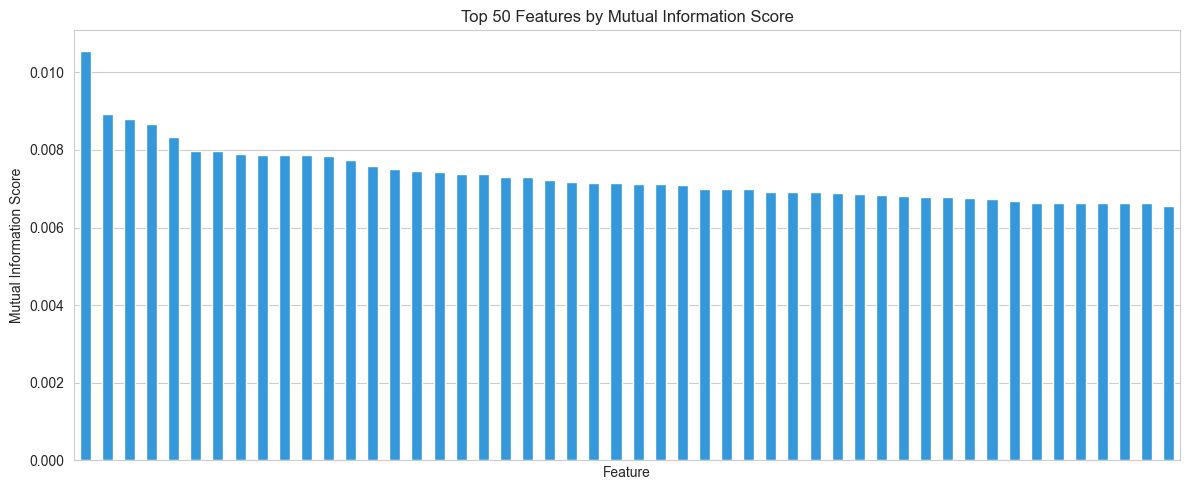

  MI score range: [0.0000, 0.0105]
  Selected 150 candidate features

  Stage 2: PR-AUC vs k elbow plot (k = 20, 50, 100, 200)...
    k=  20  PR-AUC = 0.5813 (+/-0.2533)
    k=  50  PR-AUC = 0.6063 (+/-0.2841)
    k= 100  PR-AUC = 0.7585 (+/-0.1410)


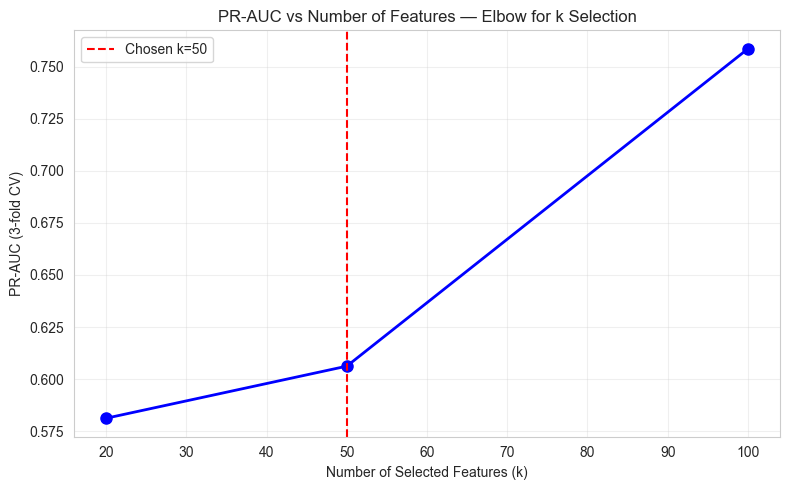


  Stage 3: Random Forest importance (class_weight='balanced')...


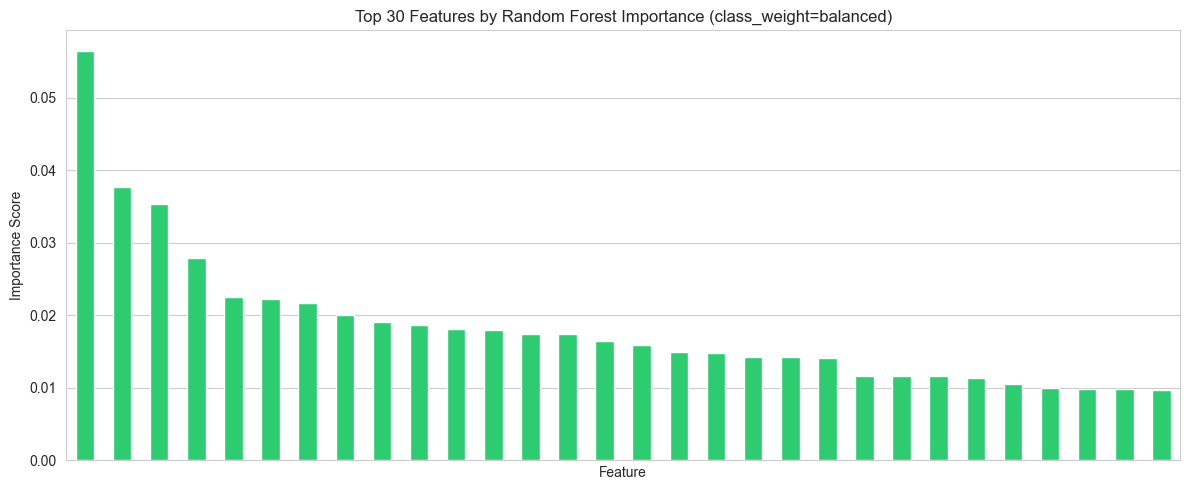

  Selected features saved to: selected_features.csv

  Final selected: 50 features
  Top 10 features: ['F3898', 'F3805', 'F1815', 'F3799', 'F3811', 'F3813', 'F3807', 'F2489', 'F1921', 'F3806']


In [8]:


def select_features_statistically(X, y, n_final_features=50, mi_scores_cache=None):
    """
    Data-driven feature selection using Mutual Information and Random Forest.

    Parameters
    ----------
    mi_scores_cache : pd.Series or None
        Pre-computed MI scores (index = feature names, values = MI scores).
        If provided, MI computation is skipped (saves ~2–5 min on large datasets).
    """
    import numpy as np
    import matplotlib.pyplot as plt
    from sklearn.feature_selection import mutual_info_classif
    from sklearn.ensemble import RandomForestClassifier
    from xgboost import XGBClassifier
    from sklearn.model_selection import StratifiedKFold, cross_val_score

    print("\n" + "="*60)
    print("STEP 3: STATISTICAL FEATURE SELECTION")
    print("="*60)

    # ── Stage 1: Mutual Information (cached if available) ─────────────────────
    if mi_scores_cache is not None:
        print("\n  Stage 1: Using cached MI scores (skipping recomputation).")
        mi_series = mi_scores_cache.sort_values(ascending=False)
    else:
        print("\n  Stage 1: Computing Mutual Information scores...")
        mi_raw = mutual_info_classif(X, y, random_state=42, n_neighbors=5)
        mi_series = pd.Series(mi_raw, index=X.columns).sort_values(ascending=False)

    # Visualize MI scores
    plt.figure(figsize=(12, 5))
    mi_series.head(50).plot(kind='bar', color='#3498db')
    plt.title('Top 50 Features by Mutual Information Score')
    plt.xlabel('Feature')
    plt.ylabel('Mutual Information Score')
    plt.xticks([])
    plt.tight_layout()
    plt.savefig('mutual_information_scores.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f"  MI score range: [{mi_series.min():.4f}, {mi_series.max():.4f}]")

    # Select top candidates (3x final desired)
    candidate_features = mi_series.head(n_final_features * 3).index.tolist()
    X_candidates = X[candidate_features]
    print(f"  Selected {len(candidate_features)} candidate features")

    # ── Stage 2: PR-AUC vs k elbow plot ───────────────────────────────────────
    # Use a light XGBoost with 3-fold CV to justify n_final_features choice.
    # Pick k at the elbow (diminishing returns in PR-AUC).
    print("\n  Stage 2: PR-AUC vs k elbow plot (k = 20, 50, 100, 200)...")

    k_values = [k for k in [20, 50, 100, 200] if k <= len(candidate_features)]
    prauc_scores = []
    cv3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

    for k in k_values:
        X_k = X_candidates[mi_series.head(k).index.tolist()]
        xgb_light = XGBClassifier(
            n_estimators=100, max_depth=4, learning_rate=0.1,
            subsample=0.8, colsample_bytree=0.8,
            objective='binary:logistic', eval_metric='aucpr',
            random_state=42, n_jobs=-1, verbosity=0
        )
        scores = cross_val_score(
            xgb_light, X_k, y,
            cv=cv3, scoring='average_precision', n_jobs=-1
        )
        prauc_scores.append(scores.mean())
        print(f"    k={k:4d}  PR-AUC = {scores.mean():.4f} (+/-{scores.std()*2:.4f})")

    plt.figure(figsize=(8, 5))
    plt.plot(k_values, prauc_scores, 'bo-', linewidth=2, markersize=8)
    plt.axvline(x=n_final_features, color='red', linestyle='--',
                label=f'Chosen k={n_final_features}')
    plt.xlabel('Number of Selected Features (k)')
    plt.ylabel('PR-AUC (3-fold CV)')
    plt.title('PR-AUC vs Number of Features — Elbow for k Selection')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('prauc_vs_k.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ── Stage 3: Random Forest with class_weight='balanced' ───────────────────
    print("\n  Stage 3: Random Forest importance (class_weight='balanced')...")
    rf = RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',  # handles minority class properly
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X_candidates, y)

    rf_importance = pd.Series(
        rf.feature_importances_,
        index=candidate_features
    ).sort_values(ascending=False)

    plt.figure(figsize=(12, 5))
    rf_importance.head(30).plot(kind='bar', color='#2ecc71')
    plt.title('Top 30 Features by Random Forest Importance (class_weight=balanced)')
    plt.xlabel('Feature')
    plt.ylabel('Importance Score')
    plt.xticks([])
    plt.tight_layout()
    plt.savefig('rf_feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Final features
    final_features = rf_importance.head(n_final_features).index.tolist()
    X_selected = X[final_features]

    # ── Save selected features to CSV for reproducibility ─────────────────────
    import os
    feat_df = pd.DataFrame({
        'feature': final_features,
        'rf_importance': rf_importance[final_features].values,
        'mi_score': mi_series[final_features].values
    })
    feat_df.to_csv('selected_features.csv', index=False)
    print(f"  Selected features saved to: selected_features.csv")

    print(f"\n  Final selected: {len(final_features)} features")
    print(f"  Top 10 features: {final_features[:10]}")

    return X_selected, final_features, mi_series, rf_importance


X_selected, selected_features, mi_scores_cached, rf_importance = \
    select_features_statistically(X_clean, y_clean)


In [9]:

print("\n" + "="*60)
print("STEP 4: DATA PREPARATION")
print("="*60)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Split data — stratified to preserve class ratio
X_train, X_test, y_train, y_test = train_test_split(
    X_selected,
    y_clean,
    test_size=0.25,
    random_state=42,
    stratify=y_clean
)

print("\nTrain-Test Split:")
print(f"  Training  : {len(X_train):,} samples")
print(f"  Testing   : {len(X_test):,}  samples")

# Class distribution
train_class0 = int((y_train == 0).sum())
train_class1 = int((y_train == 1).sum())
test_class0  = int((y_test  == 0).sum())
test_class1  = int((y_test  == 1).sum())

print("\nClass Distribution:")
print(f"  Train — Class 0: {train_class0:,} ({train_class0/len(y_train)*100:.2f}%)")
print(f"  Train — Class 1: {train_class1:,} ({train_class1/len(y_train)*100:.2f}%)")
print(f"  Test  — Class 0: {test_class0:,}  ({test_class0/len(y_test)*100:.2f}%)")
print(f"  Test  — Class 1: {test_class1:,}  ({test_class1/len(y_test)*100:.2f}%)")

# scale_pos_weight for XGBoost (XGBoost's class_weight='balanced' equivalent)
scale_pos_weight = train_class0 / train_class1 if train_class1 > 0 else 1.0
print(f"\nscale_pos_weight (XGBoost imbalance param): {scale_pos_weight:.2f}")

# ── Tree model inputs (raw DataFrames, no scaling) ────────────────────────────
# X_train and X_test keep column names — required for SHAP feature attribution.
# The cleaning_pipeline returned from clean_dataset() should be used here
# to impute X_train/X_test (fit on X_train only to prevent leakage).

# Re-fit the cleaning pipeline on X_train only
cleaning_pipeline.fit(X_train)
vt_step = cleaning_pipeline.named_steps['variance_threshold']
train_kept_cols = X_train.columns[vt_step.get_support()].tolist()

import numpy as np
X_train_imp = pd.DataFrame(
    cleaning_pipeline.transform(X_train),
    columns=train_kept_cols,
    index=X_train.index
)
# For test: transform only (no fit)
X_test_imp = pd.DataFrame(
    cleaning_pipeline.transform(X_test),
    columns=train_kept_cols,
    index=X_test.index
)

print(f"\nTree model inputs (after imputation, no scaling):")
print(f"  X_train_imp : {X_train_imp.shape}")
print(f"  X_test_imp  : {X_test_imp.shape}")

# ── Scaler available for LR baseline only ─────────────────────────────────────
lr_scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    lr_scaler.fit_transform(X_train_imp),
    columns=train_kept_cols,
    index=X_train_imp.index
)
X_test_scaled = pd.DataFrame(
    lr_scaler.transform(X_test_imp),
    columns=train_kept_cols,
    index=X_test_imp.index
)
print(f"  X_train_scaled (LR only): {X_train_scaled.shape}")

selected_feature_names = list(X_train_imp.columns)
print(f"\nFinal feature count : {len(selected_feature_names):,}")
print(f"Top 5 features      : {selected_feature_names[:5]}")
print("\nData Preparation Complete.")



STEP 4: DATA PREPARATION

Train-Test Split:
  Training  : 6,811 samples
  Testing   : 2,271  samples

Class Distribution:
  Train — Class 0: 6,750 (99.10%)
  Train — Class 1: 61 (0.90%)
  Test  — Class 0: 2,251  (99.12%)
  Test  — Class 1: 20  (0.88%)

scale_pos_weight (XGBoost imbalance param): 110.66

Tree model inputs (after imputation, no scaling):
  X_train_imp : (6811, 50)
  X_test_imp  : (2271, 50)
  X_train_scaled (LR only): (6811, 50)

Final feature count : 50
Top 5 features      : ['F3898', 'F3805', 'F1815', 'F3799', 'F3811']

Data Preparation Complete.


### 8. MODEL TRAINING & EVALUATION

In [10]:
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix
)
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import pandas as pd
import numpy as np


def find_optimal_threshold(model, X_val, y_val):
    """
    Find the decision threshold that maximises F1-score on a validation set.
    Iterates thresholds from 0.10 to 0.90 in steps of 0.01.
    Uses the held-out validation fold ONLY -- not the test set.
    """
    y_proba_val = model.predict_proba(X_val)[:, 1]
    thresholds = np.arange(0.10, 0.90, 0.01)
    best_f1, best_thr = 0.0, 0.50
    for thr in thresholds:
        y_pred_thr = (y_proba_val >= thr).astype(int)
        f1 = f1_score(y_val, y_pred_thr, zero_division=0)
        if f1 > best_f1:
            best_f1, best_thr = f1, thr
    return round(best_thr, 2), round(best_f1, 4)


def train_and_evaluate_models(X_train, X_test, y_train, y_test,
                               X_train_scaled, X_test_scaled,
                               scale_pos_weight):
    """
    Train and compare XGBoost, LightGBM, CatBoost, and Logistic Regression.

    Imbalance strategy (unified rationale):
    - XGBoost    : scale_pos_weight = n_neg / n_pos  (XGBoost's equivalent of balanced)
    - LightGBM   : class_weight='balanced'            (replaces is_unbalance=True)
    - CatBoost   : auto_class_weights='Balanced'      (CatBoost's native equivalent)
    - LogReg     : class_weight='balanced'            (standard sklearn)

    Threshold: NOT hard-coded. Found per model by maximising F1 on a held-out
    validation fold (20% of train), independent of the test set.
    """
    print("\n" + "="*70)
    print("STEP 5: MODEL TRAINING & EVALUATION")
    print("="*70)

    # Hold out a validation fold for threshold tuning (not used in final scoring)
    from sklearn.model_selection import train_test_split as tts
    X_tr, X_val, y_tr, y_val = tts(
        X_train, y_train, test_size=0.20, random_state=42, stratify=y_train
    )
    X_tr_sc, X_val_sc, _, _ = tts(
        X_train_scaled, y_train, test_size=0.20, random_state=42, stratify=y_train
    )

    # ── Model definitions ─────────────────────────────────────────────────────
    # All use class-imbalance handling appropriate for each library.
    # Hyper-params are kept consistent across models for fair comparison.

    models = {
        'XGBoost': {
            'model': XGBClassifier(
                n_estimators=500, max_depth=5, learning_rate=0.03,
                subsample=0.8, colsample_bytree=0.8,
                scale_pos_weight=scale_pos_weight,  # = n_neg/n_pos (balanced equiv)
                min_child_weight=5, gamma=1,
                reg_alpha=0.5, reg_lambda=2,
                objective='binary:logistic', eval_metric='aucpr',
                random_state=42, n_jobs=-1, verbosity=0
            ),
            'X_train': X_tr, 'X_val': X_val, 'X_test': X_test, 'scaled': False
        },
        'LightGBM': {
            'model': LGBMClassifier(
                n_estimators=500, learning_rate=0.03, num_leaves=31,
                feature_fraction=0.8, bagging_fraction=0.8, bagging_freq=5,
                reg_alpha=0.5, reg_lambda=2,
                class_weight='balanced',   # unified strategy (replaces is_unbalance)
                objective='binary', random_state=42, verbose=-1, n_jobs=-1
            ),
            'X_train': X_tr, 'X_val': X_val, 'X_test': X_test, 'scaled': False
        },
        'CatBoost': {
            'model': CatBoostClassifier(
                iterations=500, depth=6, learning_rate=0.03,
                auto_class_weights='Balanced',  # CatBoost balanced equivalent
                loss_function='Logloss', random_seed=42, verbose=0
            ),
            'X_train': X_tr, 'X_val': X_val, 'X_test': X_test, 'scaled': False
        },
        'LogisticRegression': {
            # Baseline: uses scaled inputs (tree models don't need scaling).
            # Separate StandardScaler fitted on X_train_scaled (already done in Cell 4).
            'model': LogisticRegression(
                class_weight='balanced', max_iter=1000, C=1.0,
                random_state=42, n_jobs=-1
            ),
            'X_train': X_tr_sc, 'X_val': X_val_sc,
            'X_test': X_test_scaled, 'scaled': True
        },
    }

    results = {}
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    for name, cfg in models.items():
        model    = cfg['model']
        Xt       = cfg['X_train']
        Xv       = cfg['X_val']
        Xte      = cfg['X_test']
        yt       = y_tr
        yv       = y_val

        print(f"\n{'='*50}")
        print(f"Training {name}")
        print(f"{'='*50}")

        # Cross-validation on full X_train (before val split) for fair CV estimate
        cv_scores = cross_val_score(
            model, X_train if not cfg['scaled'] else X_train_scaled,
            y_train, cv=cv, scoring='average_precision', n_jobs=-1
        )
        print(f"CV PR-AUC (5-fold): {cv_scores.mean():.4f} (+/-{cv_scores.std()*2:.4f})")

        # Fit on train portion (excluding val) for threshold tuning
        model.fit(Xt, yt)

        # Find optimal threshold on validation fold
        opt_thr, val_f1 = find_optimal_threshold(model, Xv, yv)
        print(f"Optimal threshold  : {opt_thr} (val F1 = {val_f1:.4f})")

        # Evaluate on TEST set with the optimal threshold
        y_proba = model.predict_proba(Xte)[:, 1]
        y_pred  = (y_proba >= opt_thr).astype(int)

        precision = precision_score(y_test, y_pred, zero_division=0)
        recall    = recall_score(y_test, y_pred, zero_division=0)
        f1        = f1_score(y_test, y_pred, zero_division=0)
        auc_roc   = roc_auc_score(y_test, y_proba)
        pr_auc    = average_precision_score(y_test, y_proba)

        results[name] = {
            'model': model,
            'precision': precision, 'recall': recall, 'f1': f1,
            'auc_roc': auc_roc, 'pr_auc': pr_auc,
            'cv_pr_auc': cv_scores.mean(),
            'optimal_threshold': opt_thr
        }

        print(f"\nTest Metrics (threshold={opt_thr}):")
        print(f"  Precision : {precision:.4f}")
        print(f"  Recall    : {recall:.4f}")
        print(f"  F1-Score  : {f1:.4f}")
        print(f"  PR-AUC    : {pr_auc:.4f}")
        print(f"  ROC-AUC   : {auc_roc:.4f}")

        cm = confusion_matrix(y_test, y_pred)
        print(f"\n  Confusion Matrix:")
        print(f"  TN={cm[0,0]:5d} | FP={cm[0,1]:5d}")
        print(f"  FN={cm[1,0]:5d} | TP={cm[1,1]:5d}")

    # ── Comparison table ───────────────────────────────────────────────────────
    print("\n" + "="*70)
    print("MODEL COMPARISON")
    print("="*70)

    comparison_df = pd.DataFrame(results).T[
        ['recall', 'precision', 'f1', 'pr_auc', 'auc_roc',
         'cv_pr_auc', 'optimal_threshold']
    ].sort_values('pr_auc', ascending=False)

    print(comparison_df.round(4).to_string())

    best_model_name = comparison_df.index[0]
    best_model = results[best_model_name]['model']

    print(f"\nBEST MODEL: {best_model_name}")
    print(f"  PR-AUC            : {comparison_df.loc[best_model_name,'pr_auc']:.4f}")
    print(f"  Recall            : {comparison_df.loc[best_model_name,'recall']:.4f}")
    print(f"  Optimal Threshold : {comparison_df.loc[best_model_name,'optimal_threshold']}")

    return results, best_model, best_model_name, comparison_df


In [11]:
# ============================================================
# Run model training & evaluation
# ============================================================
results, best_model, best_model_name, comparison_df = train_and_evaluate_models(
    X_train=X_train_imp,
    X_test=X_test_imp,
    y_train=y_train,
    y_test=y_test,
    X_train_scaled=X_train_scaled,
    X_test_scaled=X_test_scaled,
    scale_pos_weight=scale_pos_weight
)



STEP 5: MODEL TRAINING & EVALUATION

Training XGBoost
CV PR-AUC (5-fold): 0.7684 (+/-0.1607)
Optimal threshold  : 0.56 (val F1 = 0.8696)

Test Metrics (threshold=0.56):
  Precision : 0.7059
  Recall    : 0.6000
  F1-Score  : 0.6486
  PR-AUC    : 0.7062
  ROC-AUC   : 0.9916

  Confusion Matrix:
  TN= 2246 | FP=    5
  FN=    8 | TP=   12

Training LightGBM
CV PR-AUC (5-fold): 0.7583 (+/-0.1834)
Optimal threshold  : 0.71 (val F1 = 0.9091)

Test Metrics (threshold=0.71):
  Precision : 0.8571
  Recall    : 0.6000
  F1-Score  : 0.7059
  PR-AUC    : 0.6886
  ROC-AUC   : 0.9892

  Confusion Matrix:
  TN= 2249 | FP=    2
  FN=    8 | TP=   12

Training CatBoost
CV PR-AUC (5-fold): 0.7937 (+/-0.1615)
Optimal threshold  : 0.65 (val F1 = 0.9167)

Test Metrics (threshold=0.65):
  Precision : 0.6842
  Recall    : 0.6500
  F1-Score  : 0.6667
  PR-AUC    : 0.7551
  ROC-AUC   : 0.9942

  Confusion Matrix:
  TN= 2245 | FP=    6
  FN=    7 | TP=   13

Training LogisticRegression
CV PR-AUC (5-fold): 0.1

### THRESHOLD OPTIMISATION — PR Curve & Operating Points

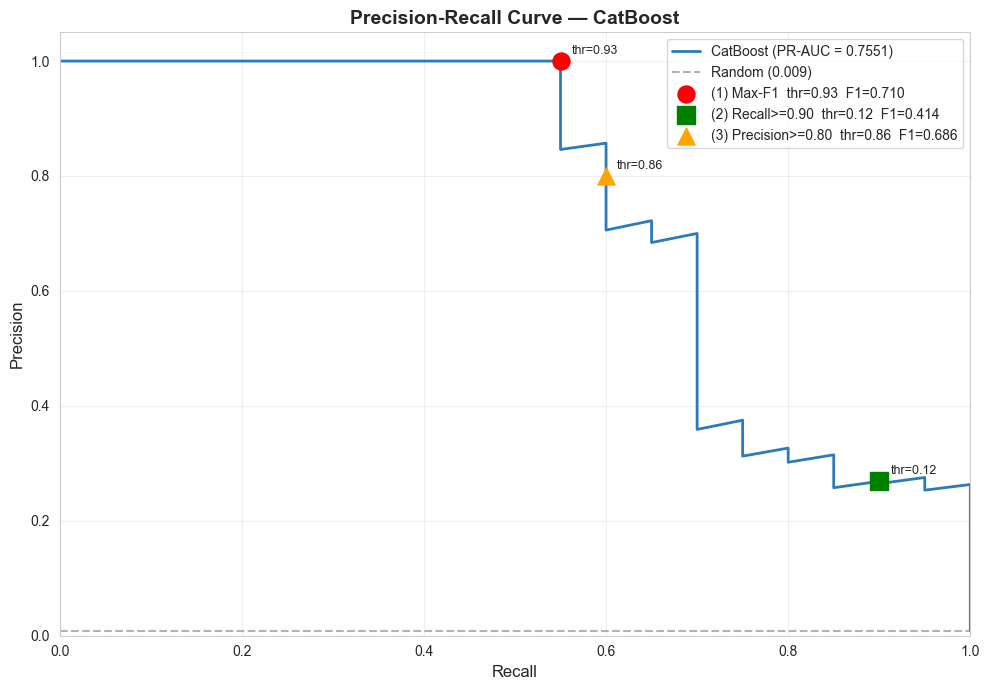


OPERATING POINT DECISION TABLE — CatBoost
  Operating Point                 Threshold  Precision     Recall       F1
  ---------------------------------------------------------------
  (1) Max-F1                           0.93     1.0000     0.5500   0.7097
  (2) Recall >= 0.90                   0.12     0.2687     0.9000   0.4138
  (3) Precision >= 0.80                0.86     0.8000     0.6000   0.6857
  Stakeholder guide:
  -> Use (1) Max-F1 for balanced detection.
  -> Use (2) Recall>=0.90 to catch 90%+ of fraud (higher FP cost).
  -> Use (3) Precision>=0.80 to minimise false alarms (miss more fraud).


In [12]:
# =============================================================================
# THRESHOLD OPTIMISATION
# Plot the PR curve for the best model on the test set.
# Mark three operating points:
#   (1) max-F1 threshold
#   (2) threshold at Recall >= 0.90  (high-recall / fraud use case)
#   (3) threshold at Precision >= 0.80
# Print a business-friendly decision table.
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    precision_recall_curve, average_precision_score,
    f1_score, precision_score, recall_score
)

# ── Retrieve best model outputs ───────────────────────────────────────────────
best_cfg    = results[best_model_name]
best_m      = best_cfg['model']

# Use the correct inputs for the best model
if best_model_name == 'LogisticRegression':
    X_te_best = X_test_scaled
else:
    X_te_best = X_test_imp

y_proba_best = best_m.predict_proba(X_te_best)[:, 1]

# ── Compute PR curve ──────────────────────────────────────────────────────────
precs, recs, thrs = precision_recall_curve(y_test, y_proba_best)
pr_auc = average_precision_score(y_test, y_proba_best)

# ── Operating point 1: max-F1 threshold ──────────────────────────────────────
f1_scores = np.where(
    (precs[:-1] + recs[:-1]) > 0,
    2 * precs[:-1] * recs[:-1] / (precs[:-1] + recs[:-1]),
    0.0
)
idx1    = int(np.argmax(f1_scores))
thr1    = float(thrs[idx1])
p1, r1  = float(precs[idx1]), float(recs[idx1])
f1_1    = float(f1_scores[idx1])

# ── Operating point 2: Recall >= 0.90 ────────────────────────────────────────
mask_r90 = recs[:-1] >= 0.90
if mask_r90.any():
    idx2   = int(np.where(mask_r90)[0][-1])   # highest threshold still hitting 0.90 recall
    thr2   = float(thrs[idx2])
    p2, r2 = float(precs[idx2]), float(recs[idx2])
    f1_2   = 2*p2*r2/(p2+r2) if (p2+r2) > 0 else 0.0
else:
    thr2, p2, r2, f1_2 = 0.0, 0.0, 1.0, 0.0
    print("  WARNING: Recall>=0.90 not achievable — marking at Recall=1.0")

# ── Operating point 3: Precision >= 0.80 ─────────────────────────────────────
mask_p80 = precs[:-1] >= 0.80
if mask_p80.any():
    idx3   = int(np.where(mask_p80)[0][0])    # lowest threshold hitting 0.80 precision
    thr3   = float(thrs[idx3])
    p3, r3 = float(precs[idx3]), float(recs[idx3])
    f1_3   = 2*p3*r3/(p3+r3) if (p3+r3) > 0 else 0.0
else:
    thr3, p3, r3, f1_3 = 1.0, 1.0, 0.0, 0.0
    print("  WARNING: Precision>=0.80 not achievable — marking at Precision=1.0")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))

ax.plot(recs, precs, lw=2, color='#2c7bb6',
        label=f'{best_model_name} (PR-AUC = {pr_auc:.4f})')

# Random classifier baseline
ax.axhline(y=y_test.mean(), color='grey', linestyle='--',
           alpha=0.6, label=f'Random ({y_test.mean():.3f})')

# Operating points
ops = [
    (r1, p1, thr1, f1_1, 'red',    'o', '(1) Max-F1'),
    (r2, p2, thr2, f1_2, 'green',  's', '(2) Recall>=0.90'),
    (r3, p3, thr3, f1_3, 'orange', '^', '(3) Precision>=0.80'),
]
for r_op, p_op, t_op, f_op, col, mk, lbl in ops:
    ax.scatter(r_op, p_op, color=col, marker=mk, s=150, zorder=5,
               label=f'{lbl}  thr={t_op:.2f}  F1={f_op:.3f}')
    ax.annotate(f'thr={t_op:.2f}', (r_op, p_op),
                textcoords='offset points', xytext=(8, 5), fontsize=9)

ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title(f'Precision-Recall Curve — {best_model_name}', fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='upper right')
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])

plt.tight_layout()
plt.savefig('pr_curve_best_model.png', dpi=200, bbox_inches='tight')
plt.show()

# ── Business decision table ───────────────────────────────────────────────────
print(f"\n{'='*65}")
print(f"OPERATING POINT DECISION TABLE — {best_model_name}")
print(f"{'='*65}")
print(f"  {'Operating Point':<30} {'Threshold':>10} {'Precision':>10} {'Recall':>10} {'F1':>8}")
print(f"  {'-'*63}")
for label, thr, p, r, f in [
    ('(1) Max-F1',          thr1, p1, r1, f1_1),
    ('(2) Recall >= 0.90',  thr2, p2, r2, f1_2),
    ('(3) Precision >= 0.80', thr3, p3, r3, f1_3),
]:
    print(f"  {label:<30} {thr:>10.2f} {p:>10.4f} {r:>10.4f} {f:>8.4f}")
print(f"{'='*65}")
print("  Stakeholder guide:")
print("  -> Use (1) Max-F1 for balanced detection.")
print("  -> Use (2) Recall>=0.90 to catch 90%+ of fraud (higher FP cost).")
print("  -> Use (3) Precision>=0.80 to minimise false alarms (miss more fraud).")

# Store operating points for use in the dashboard
op_thresh_best = thr1
op_prec_best   = p1
op_rec_best    = r1
op_f1_best     = f1_1


### ROC CURVES — All Models Comparison

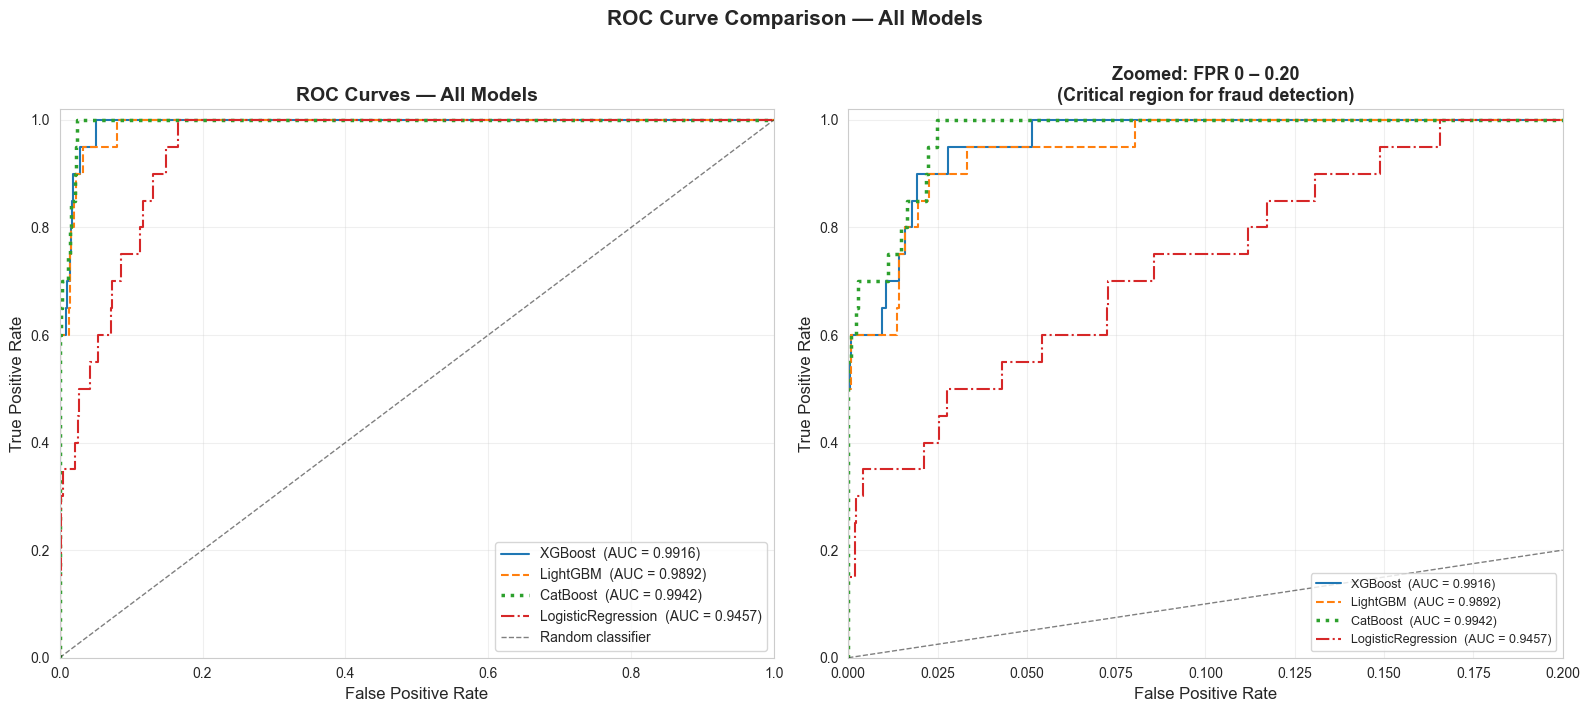

Saved: roc_curves_comparison.png


In [13]:
# =============================================================================
# ROC CURVES — all models on one plot + zoomed low-FPR panel
# Line styles chosen for greyscale readability.
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

line_styles = ['-', '--', ':', '-.']
colors      = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
model_order = ['XGBoost', 'LightGBM', 'CatBoost', 'LogisticRegression']

fig, (ax_main, ax_zoom) = plt.subplots(1, 2, figsize=(16, 7))

for idx, name in enumerate(model_order):
    if name not in results:
        continue
    m   = results[name]['model']
    Xte = X_test_scaled if name == 'LogisticRegression' else X_test_imp

    y_prob = m.predict_proba(Xte)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val = roc_auc_score(y_test, y_prob)
    ls  = line_styles[idx % len(line_styles)]
    col = colors[idx % len(colors)]
    lw  = 2.5 if name == best_model_name else 1.5

    ax_main.plot(fpr, tpr, linestyle=ls, color=col, linewidth=lw,
                 label=f'{name}  (AUC = {auc_val:.4f})')
    ax_zoom.plot(fpr, tpr, linestyle=ls, color=col, linewidth=lw,
                 label=f'{name}  (AUC = {auc_val:.4f})')

# Diagonal baseline
ax_main.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Random classifier')
ax_zoom.plot([0, 0.2], [0, 0.2], 'k--', lw=1, alpha=0.5)

# Main plot formatting
ax_main.set_xlabel('False Positive Rate', fontsize=12)
ax_main.set_ylabel('True Positive Rate', fontsize=12)
ax_main.set_title('ROC Curves — All Models', fontsize=14, fontweight='bold')
ax_main.legend(fontsize=10, loc='lower right')
ax_main.grid(True, alpha=0.3)
ax_main.set_xlim([0, 1])
ax_main.set_ylim([0, 1.02])

# Zoomed panel (FPR 0 – 0.20)
ax_zoom.set_xlabel('False Positive Rate', fontsize=12)
ax_zoom.set_ylabel('True Positive Rate', fontsize=12)
ax_zoom.set_title('Zoomed: FPR 0 – 0.20\n(Critical region for fraud detection)',
                  fontsize=13, fontweight='bold')
ax_zoom.legend(fontsize=9, loc='lower right')
ax_zoom.grid(True, alpha=0.3)
ax_zoom.set_xlim([0, 0.20])
ax_zoom.set_ylim([0, 1.02])

plt.suptitle('ROC Curve Comparison — All Models', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('roc_curves_comparison.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: roc_curves_comparison.png")


### SHAP — Global Explainability

Background dataset has 6811 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=6811 when initializing the masker.


Computing SHAP values on 500-sample stratified subset...


 95%|=================== | 474/500 [00:28<00:01]       


TOP 15 FEATURES — Mean Absolute SHAP Value
  Rank  Feature                    Mean |SHAP|
  -------------------------------------------
  1     F3898                          0.95929
  2     F3748                          0.14607
  3     F2486                          0.13960
  4     F2137                          0.12330
  5     F3812                          0.12315
  6     F3805                          0.12088
  7     F1923                          0.11956
  8     F1597                          0.11808
  9     F270                           0.11487
  10    F2489                          0.11221
  11    F2385                          0.10109
  12    F3807                          0.09843
  13    F3811                          0.09773
  14    F3640                          0.09622
  15    F3532                          0.09576


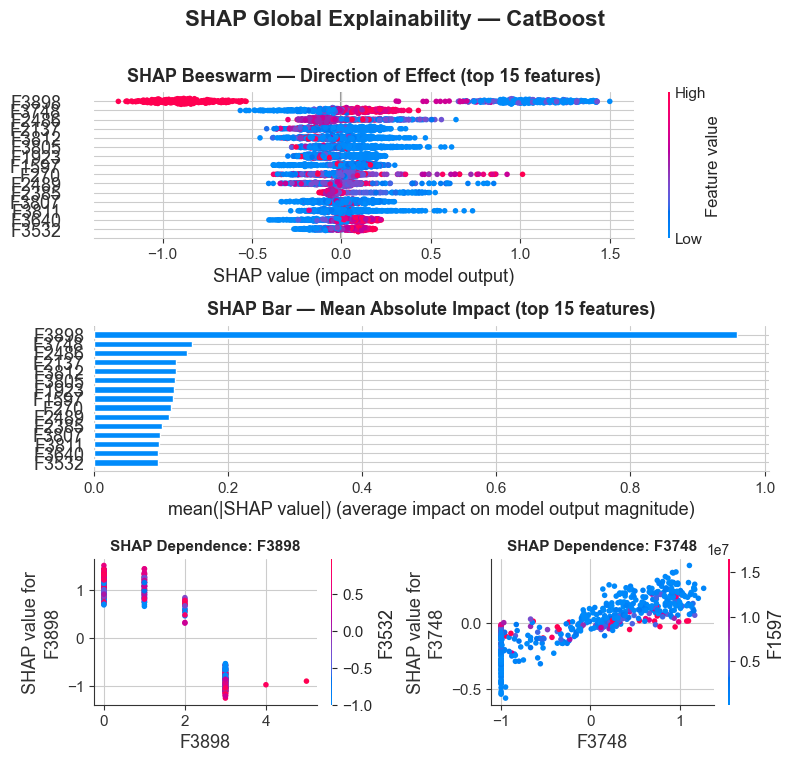

Saved: shap_explainability.png


In [14]:
# =============================================================================
# SHAP GLOBAL EXPLAINABILITY
# - TreeExplainer on best model, background = X_train_imp (full training set)
# - SHAP values computed on 500-sample stratified subset of X_test_imp
# - Three panels: beeswarm, bar summary, dependence plots for top-2 features
# =============================================================================

import shap
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedShuffleSplit

# Only tree models support TreeExplainer directly
if best_model_name in ('XGBoost', 'LightGBM', 'CatBoost'):
    explainer = shap.TreeExplainer(best_m, data=X_train_imp)
else:
    explainer = shap.LinearExplainer(best_m, X_train_scaled)

# ── Stratified 500-sample subset of X_test ────────────────────────────────────
sss = StratifiedShuffleSplit(n_splits=1, test_size=min(500, len(y_test)),
                              random_state=42)
_, shap_idx = next(sss.split(X_test_imp, y_test))
if best_model_name == 'LogisticRegression':
    X_shap = X_test_scaled.iloc[shap_idx]
else:
    X_shap = X_test_imp.iloc[shap_idx]
y_shap = y_test.iloc[shap_idx]

print(f"Computing SHAP values on {len(shap_idx)}-sample stratified subset...")
shap_values = explainer(X_shap)

# For binary classification some explainers return 2 outputs — take class 1
sv = shap_values
if hasattr(sv, 'values') and sv.values.ndim == 3:
    # shape (n_samples, n_features, 2) — take class 1 slice
    import shap as shap_lib
    sv = shap_lib.Explanation(
        values=sv.values[:, :, 1],
        base_values=sv.base_values[:, 1] if sv.base_values.ndim == 2 else sv.base_values,
        data=sv.data,
        feature_names=sv.feature_names
    )

# ── Mean absolute SHAP table (top 15) ─────────────────────────────────────────
mean_abs_shap = np.abs(sv.values).mean(axis=0)
feat_names    = list(X_shap.columns)
shap_series   = sorted(zip(feat_names, mean_abs_shap), key=lambda x: -x[1])

print(f"\n{'='*50}")
print("TOP 15 FEATURES — Mean Absolute SHAP Value")
print(f"{'='*50}")
print(f"  {'Rank':<5} {'Feature':<25} {'Mean |SHAP|':>12}")
print(f"  {'-'*43}")
for rank, (feat, val) in enumerate(shap_series[:15], 1):
    print(f"  {rank:<5} {feat:<25} {val:>12.5f}")
print(f"{'='*50}")

top2_feats = [shap_series[0][0], shap_series[1][0]]

# ── Three-panel figure ─────────────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 18))

# Panel 1: Beeswarm (direction of effect per feature)
ax1 = fig.add_subplot(3, 1, 1)
plt.sca(ax1)
shap.summary_plot(sv, X_shap, show=False, max_display=15,
                  feature_names=feat_names)
ax1.set_title("SHAP Beeswarm — Direction of Effect (top 15 features)",
              fontsize=13, fontweight='bold', pad=8)

# Panel 2: Bar (mean absolute impact)
ax2 = fig.add_subplot(3, 1, 2)
plt.sca(ax2)
shap.summary_plot(sv, X_shap, plot_type='bar', show=False, max_display=15,
                  feature_names=feat_names)
ax2.set_title("SHAP Bar — Mean Absolute Impact (top 15 features)",
              fontsize=13, fontweight='bold', pad=8)

# Panel 3: Dependence plots for top-2 features (auto-selects interaction feature)
ax3 = fig.add_subplot(3, 2, 5)
plt.sca(ax3)
shap.dependence_plot(top2_feats[0], sv.values, X_shap,
                     interaction_index='auto',
                     feature_names=feat_names, ax=ax3, show=False)
ax3.set_title(f"SHAP Dependence: {top2_feats[0]}", fontsize=11, fontweight='bold')

ax4 = fig.add_subplot(3, 2, 6)
plt.sca(ax4)
shap.dependence_plot(top2_feats[1], sv.values, X_shap,
                     interaction_index='auto',
                     feature_names=feat_names, ax=ax4, show=False)
ax4.set_title(f"SHAP Dependence: {top2_feats[1]}", fontsize=11, fontweight='bold')

plt.suptitle(f"SHAP Global Explainability — {best_model_name}",
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('shap_explainability.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: shap_explainability.png")


### SHAP — Local Case Studies (True Positive vs False Negative)


Case 1: True Positive (highest prob)
  Actual Label : 1
  Predicted p  : 0.9998  (threshold=0.93)
  Top-3 SHAP feature interpretation:
  Feature F3898: pushed score 1.1116 higher (value=0.0000, class-0 median=3.0000)
  Feature F270: pushed score 0.9888 higher (value=1.0000, class-0 median=0.4100)
  Feature F3811: pushed score 0.8849 higher (value=33913.0000, class-0 median=838507.2700)

Case 2: False Negative (highest prob miss)
  Actual Label : 1
  Predicted p  : 0.8626  (threshold=0.93)
  Top-3 SHAP feature interpretation:
  Feature F3898: pushed score 1.4037 higher (value=1.0000, class-0 median=3.0000)
  Feature F270: pushed score 0.8758 higher (value=0.6500, class-0 median=0.4100)
  Feature F2489: pushed score 0.8466 higher (value=0.5500, class-0 median=1.4800)


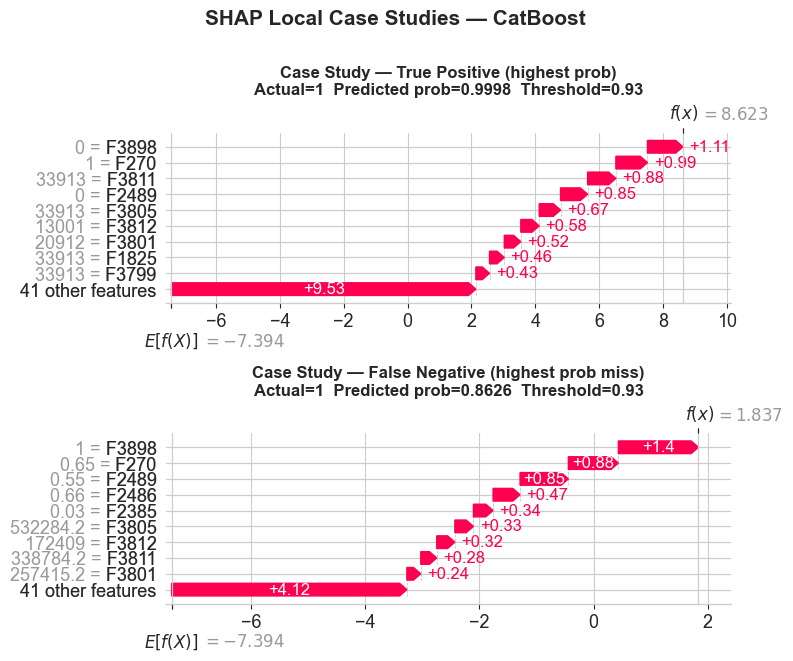

Saved: shap_case_studies.png


In [15]:
# =============================================================================
# SHAP LOCAL CASE STUDIES
# Case 1: True Positive with highest predicted probability
# Case 2: False Negative (model missed it) with highest predicted probability
# Waterfall plots + plain-language interpretation
# =============================================================================

import shap
import numpy as np
import matplotlib.pyplot as plt

if best_model_name == 'LogisticRegression':
    X_te_local = X_test_scaled
else:
    X_te_local = X_test_imp

y_prob_all = best_m.predict_proba(X_te_local)[:, 1]
y_pred_all = (y_prob_all >= op_thresh_best).astype(int)

feat_names = list(X_te_local.columns)

# ── Case 1: True Positive with highest predicted probability ──────────────────
tp_mask  = (y_test.values == 1) & (y_pred_all == 1)
if tp_mask.sum() > 0:
    tp_probs = y_prob_all[tp_mask]
    tp_idx   = int(np.where(tp_mask)[0][np.argmax(tp_probs)])
else:
    # Fallback: highest-probability actual positive
    tp_idx = int(np.argmax(y_prob_all * (y_test.values == 1)))

# ── Case 2: False Negative with highest predicted probability among misses ─────
fn_mask  = (y_test.values == 1) & (y_pred_all == 0)
if fn_mask.sum() > 0:
    fn_probs = y_prob_all[fn_mask]
    fn_idx   = int(np.where(fn_mask)[0][np.argmax(fn_probs)])
    fn_available = True
else:
    print("  NOTE: No false negatives in test set — skipping FN case study.")
    fn_available = False

# Compute SHAP for the two samples
X_cases = X_te_local.iloc[[tp_idx] + ([fn_idx] if fn_available else [])]
shap_cases = explainer(X_cases)

if hasattr(shap_cases, 'values') and shap_cases.values.ndim == 3:
    import shap as shap_lib
    shap_cases = shap_lib.Explanation(
        values=shap_cases.values[:, :, 1],
        base_values=shap_cases.base_values[:, 1] if shap_cases.base_values.ndim == 2
                    else shap_cases.base_values,
        data=shap_cases.data,
        feature_names=shap_cases.feature_names
    )

# ── Helper: plain-language interpretation for top-3 SHAP features ─────────────
def interpret_shap(sv_row, X_row, feat_names, class0_medians):
    shap_vals = sv_row.values
    feat_vals = X_row.values
    ranked    = np.argsort(np.abs(shap_vals))[::-1][:3]
    lines     = []
    for r in ranked:
        fn  = feat_names[r]
        sv  = shap_vals[r]
        fv  = feat_vals[r]
        med = class0_medians.get(fn, float('nan'))
        direction = "higher" if sv > 0 else "lower"
        lines.append(
            f"  Feature {fn}: pushed score {abs(sv):.4f} {direction} "
            f"(value={fv:.4f}, class-0 median={med:.4f})"
        )
    return lines

# Compute class-0 medians for reference
if best_model_name == 'LogisticRegression':
    X_ref = X_train_scaled
else:
    X_ref = X_train_imp
class0_medians = X_ref[y_train == 0].median().to_dict()

# ── Plot ──────────────────────────────────────────────────────────────────────
n_cases = 2 if fn_available else 1
fig, axes = plt.subplots(n_cases, 1, figsize=(14, 8 * n_cases))
if n_cases == 1:
    axes = [axes]

case_labels = ['True Positive (highest prob)', 'False Negative (highest prob miss)']
case_idxs   = [0] + ([1] if fn_available else [])

for panel_i, (case_label, si) in enumerate(zip(case_labels[:n_cases], case_idxs)):
    plt.sca(axes[panel_i])
    sv_row = shap_cases[si]
    actual_label = y_test.iloc[tp_idx if si == 0 else fn_idx]
    pred_prob    = y_prob_all[tp_idx if si == 0 else fn_idx]

    shap.waterfall_plot(sv_row, max_display=10, show=False)
    axes[panel_i].set_title(
        f"Case Study — {case_label}\n"
        f"Actual={actual_label}  Predicted prob={pred_prob:.4f}  Threshold={op_thresh_best:.2f}",
        fontsize=12, fontweight='bold'
    )

    # Print interpretation below
    X_row = X_te_local.iloc[tp_idx if si == 0 else fn_idx]
    interp = interpret_shap(sv_row, X_row, feat_names, class0_medians)
    print(f"\n{'='*60}")
    print(f"Case {panel_i+1}: {case_label}")
    print(f"  Actual Label : {actual_label}")
    print(f"  Predicted p  : {pred_prob:.4f}  (threshold={op_thresh_best:.2f})")
    print("  Top-3 SHAP feature interpretation:")
    for line in interp:
        print(line)

plt.suptitle(f"SHAP Local Case Studies — {best_model_name}",
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('shap_case_studies.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: shap_case_studies.png")


### FINAL EVALUATION DASHBOARD (3x3)

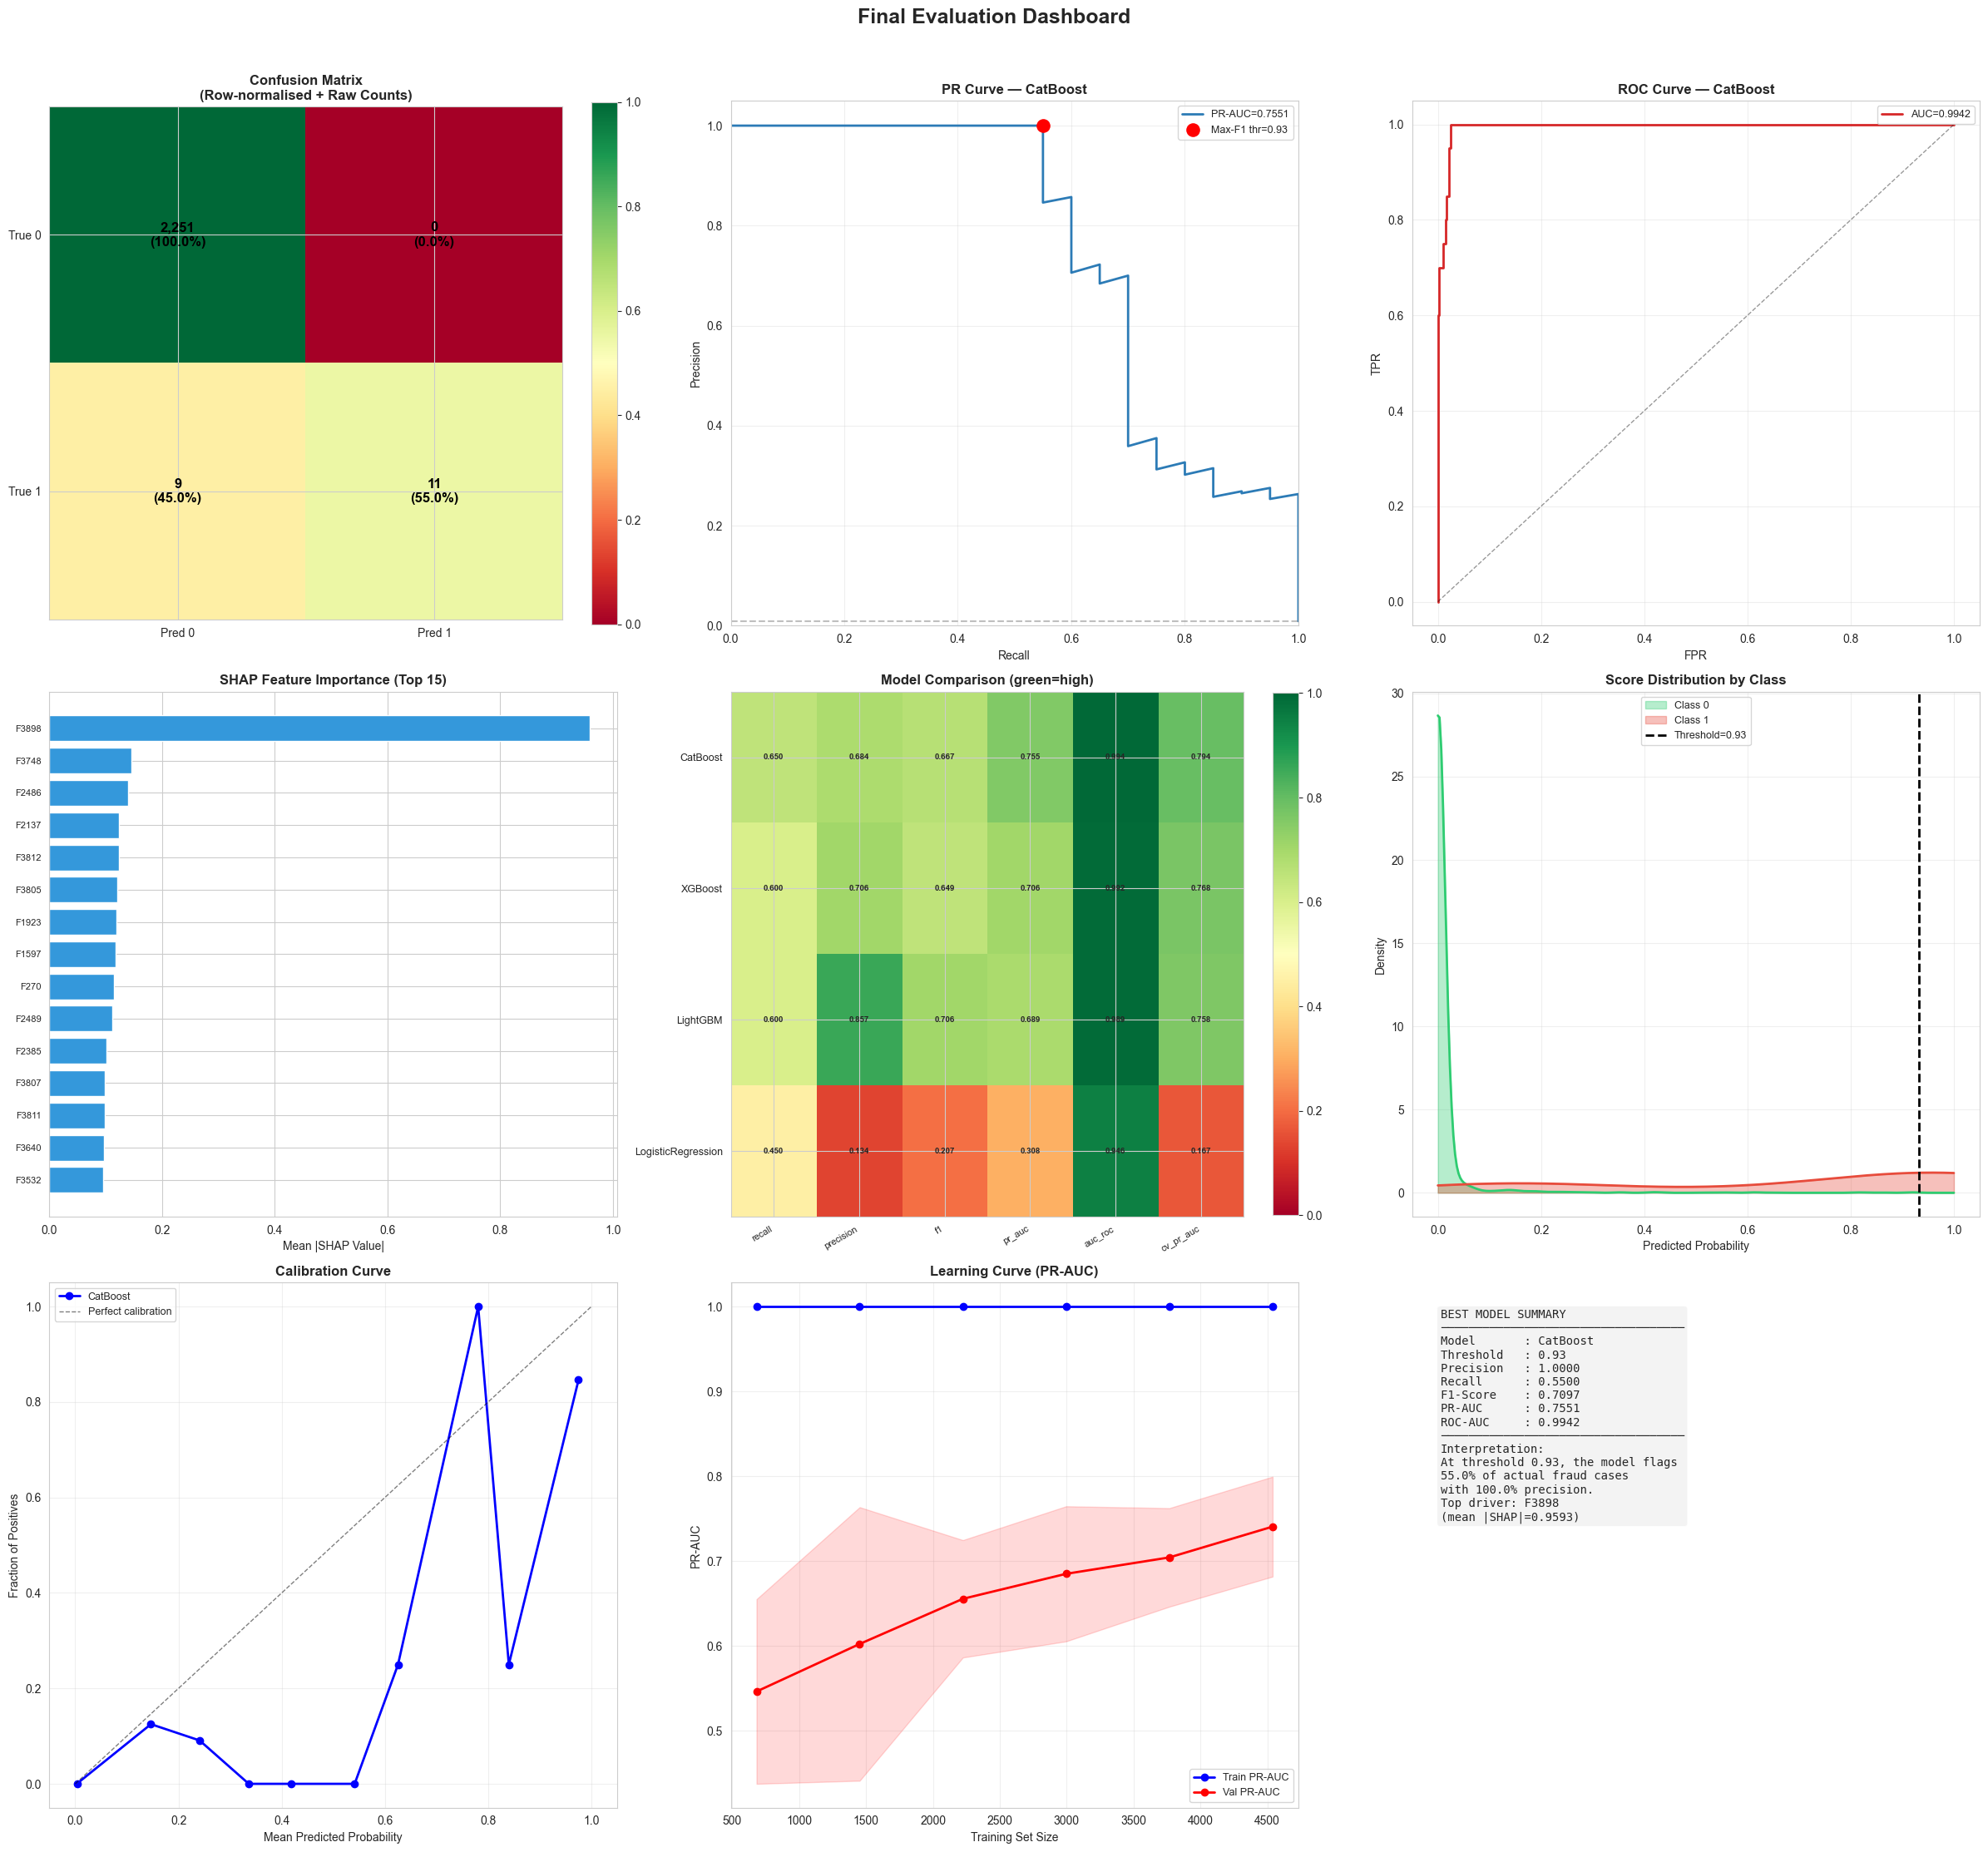

Saved: final_evaluation_dashboard.png


In [16]:
# =============================================================================
# FINAL EVALUATION DASHBOARD — 3x3 figure
# (1) Confusion matrix heatmap (row-normalised + raw counts)
# (2) PR curve with operating point
# (3) ROC curve
# (4) SHAP bar summary (top 15)
# (5) Model comparison heatmap (green-to-red)
# (6) Score distribution KDE (class 0 vs 1) with threshold
# (7) Calibration curve
# (8) Learning curve (PR-AUC vs training size)
# (9) Text summary box
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.metrics import (
    confusion_matrix, precision_recall_curve,
    roc_curve, average_precision_score, roc_auc_score,
    f1_score, precision_score, recall_score
)
from sklearn.calibration import calibration_curve
from sklearn.model_selection import StratifiedShuffleSplit, cross_val_score, StratifiedKFold

fig = plt.figure(figsize=(24, 22))

# ── Panel 1: Confusion Matrix ─────────────────────────────────────────────────
ax1 = fig.add_subplot(3, 3, 1)
y_pred_best = (y_prob_all >= op_thresh_best).astype(int)
cm = confusion_matrix(y_test, y_pred_best)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

im = ax1.imshow(cm_norm, cmap='RdYlGn', vmin=0, vmax=1)
plt.colorbar(im, ax=ax1, fraction=0.046)
for i in range(2):
    for j in range(2):
        ax1.text(j, i, f'{cm[i,j]:,}\n({cm_norm[i,j]:.1%})',
                 ha='center', va='center', fontsize=12, fontweight='bold',
                 color='black')
ax1.set_xticks([0, 1]); ax1.set_yticks([0, 1])
ax1.set_xticklabels(['Pred 0', 'Pred 1']); ax1.set_yticklabels(['True 0', 'True 1'])
ax1.set_title('Confusion Matrix\n(Row-normalised + Raw Counts)', fontweight='bold')

# ── Panel 2: PR Curve with operating point ─────────────────────────────────────
ax2 = fig.add_subplot(3, 3, 2)
ax2.plot(recs, precs, lw=2, color='#2c7bb6', label=f'PR-AUC={pr_auc:.4f}')
ax2.scatter(op_rec_best, op_prec_best, color='red', s=120, zorder=5,
            label=f'Max-F1 thr={op_thresh_best:.2f}')
ax2.axhline(y=y_test.mean(), color='grey', linestyle='--', alpha=0.5)
ax2.set_xlabel('Recall'); ax2.set_ylabel('Precision')
ax2.set_title(f'PR Curve — {best_model_name}', fontweight='bold')
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3)
ax2.set_xlim([0, 1]); ax2.set_ylim([0, 1.05])

# ── Panel 3: ROC Curve ────────────────────────────────────────────────────────
ax3 = fig.add_subplot(3, 3, 3)
fpr_b, tpr_b, _ = roc_curve(y_test, y_prob_all)
auc_b = roc_auc_score(y_test, y_prob_all)
ax3.plot(fpr_b, tpr_b, lw=2, color='#d62728', label=f'AUC={auc_b:.4f}')
ax3.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.4)
ax3.set_xlabel('FPR'); ax3.set_ylabel('TPR')
ax3.set_title(f'ROC Curve — {best_model_name}', fontweight='bold')
ax3.legend(fontsize=9); ax3.grid(True, alpha=0.3)

# ── Panel 4: SHAP Bar Summary (top 15) ────────────────────────────────────────
ax4 = fig.add_subplot(3, 3, 4)
top15_names  = [f for f, _ in shap_series[:15]]
top15_values = [v for _, v in shap_series[:15]]
ax4.barh(range(len(top15_names)), top15_values[::-1], color='#3498db')
ax4.set_yticks(range(len(top15_names)))
ax4.set_yticklabels(top15_names[::-1], fontsize=8)
ax4.set_xlabel('Mean |SHAP Value|')
ax4.set_title('SHAP Feature Importance (Top 15)', fontweight='bold')

# ── Panel 5: Model Comparison Heatmap ─────────────────────────────────────────
ax5 = fig.add_subplot(3, 3, 5)
metric_cols = ['recall', 'precision', 'f1', 'pr_auc', 'auc_roc', 'cv_pr_auc']
comp_data = comparison_df[metric_cols].astype(float)
heat_vals = comp_data.values
im5 = ax5.imshow(heat_vals, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
plt.colorbar(im5, ax=ax5, fraction=0.046)
ax5.set_xticks(range(len(metric_cols)))
ax5.set_xticklabels(metric_cols, rotation=30, ha='right', fontsize=8)
ax5.set_yticks(range(len(comp_data)))
ax5.set_yticklabels(comp_data.index, fontsize=9)
for i in range(len(comp_data)):
    for j in range(len(metric_cols)):
        ax5.text(j, i, f'{heat_vals[i,j]:.3f}', ha='center', va='center',
                 fontsize=7, fontweight='bold')
ax5.set_title('Model Comparison (green=high)', fontweight='bold')

# ── Panel 6: Score Distribution KDE ──────────────────────────────────────────
ax6 = fig.add_subplot(3, 3, 6)
from scipy.stats import gaussian_kde
for cls, col, lbl in [(0, '#2ecc71', 'Class 0'), (1, '#e74c3c', 'Class 1')]:
    scores_cls = y_prob_all[y_test.values == cls]
    if len(scores_cls) > 1:
        kde = gaussian_kde(scores_cls, bw_method='scott')
        xs  = np.linspace(0, 1, 300)
        ax6.fill_between(xs, kde(xs), alpha=0.35, color=col, label=lbl)
        ax6.plot(xs, kde(xs), color=col, lw=2)
ax6.axvline(x=op_thresh_best, color='black', linestyle='--', linewidth=2,
            label=f'Threshold={op_thresh_best:.2f}')
ax6.set_xlabel('Predicted Probability'); ax6.set_ylabel('Density')
ax6.set_title('Score Distribution by Class', fontweight='bold')
ax6.legend(fontsize=9); ax6.grid(True, alpha=0.3)

# ── Panel 7: Calibration Curve ────────────────────────────────────────────────
ax7 = fig.add_subplot(3, 3, 7)
frac_pos, mean_pred = calibration_curve(y_test, y_prob_all, n_bins=10)
ax7.plot(mean_pred, frac_pos, 'bo-', lw=2, markersize=6, label=best_model_name)
ax7.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Perfect calibration')
ax7.set_xlabel('Mean Predicted Probability'); ax7.set_ylabel('Fraction of Positives')
ax7.set_title('Calibration Curve', fontweight='bold')
ax7.legend(fontsize=9); ax7.grid(True, alpha=0.3)

# ── Panel 8: Learning Curve (PR-AUC vs training size) ─────────────────────────
ax8 = fig.add_subplot(3, 3, 8)
from sklearn.model_selection import learning_curve
train_sizes = np.linspace(0.15, 1.0, 6)
cv_lc = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Use a lightweight model for speed
from xgboost import XGBClassifier as XGBC
lc_model = XGBC(n_estimators=100, max_depth=4, learning_rate=0.1,
                scale_pos_weight=scale_pos_weight,
                random_state=42, n_jobs=-1, verbosity=0)

X_lc = X_train_imp; y_lc = y_train
ts, train_sc, val_sc = learning_curve(
    lc_model, X_lc, y_lc,
    train_sizes=train_sizes, cv=cv_lc,
    scoring='average_precision', n_jobs=-1
)
ax8.plot(ts, train_sc.mean(axis=1), 'b-o', label='Train PR-AUC', lw=2)
ax8.plot(ts, val_sc.mean(axis=1),   'r-o', label='Val PR-AUC',   lw=2)
ax8.fill_between(ts,
    train_sc.mean(axis=1) - train_sc.std(axis=1),
    train_sc.mean(axis=1) + train_sc.std(axis=1), alpha=0.15, color='blue')
ax8.fill_between(ts,
    val_sc.mean(axis=1) - val_sc.std(axis=1),
    val_sc.mean(axis=1) + val_sc.std(axis=1), alpha=0.15, color='red')
ax8.set_xlabel('Training Set Size'); ax8.set_ylabel('PR-AUC')
ax8.set_title('Learning Curve (PR-AUC)', fontweight='bold')
ax8.legend(fontsize=9); ax8.grid(True, alpha=0.3)

# ── Panel 9: Text Summary Box ─────────────────────────────────────────────────
ax9 = fig.add_subplot(3, 3, 9)
ax9.axis('off')
summary_text = (
    f"BEST MODEL SUMMARY\n"
    f"{'─'*35}\n"
    f"Model       : {best_model_name}\n"
    f"Threshold   : {op_thresh_best:.2f}\n"
    f"Precision   : {op_prec_best:.4f}\n"
    f"Recall      : {op_rec_best:.4f}\n"
    f"F1-Score    : {op_f1_best:.4f}\n"
    f"PR-AUC      : {pr_auc:.4f}\n"
    f"ROC-AUC     : {auc_b:.4f}\n"
    f"{'─'*35}\n"
    f"Interpretation:\n"
    f"At threshold {op_thresh_best:.2f}, the model flags\n"
    f"{op_rec_best:.1%} of actual fraud cases\n"
    f"with {op_prec_best:.1%} precision.\n"
    f"Top driver: {shap_series[0][0]}\n"
    f"(mean |SHAP|={shap_series[0][1]:.4f})"
)
ax9.text(0.05, 0.95, summary_text, transform=ax9.transAxes,
         fontsize=10, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='#f0f0f0', alpha=0.8))

plt.suptitle('Final Evaluation Dashboard', fontsize=18, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('final_evaluation_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: final_evaluation_dashboard.png")


### MODEL PERSISTENCE & REPRODUCIBILITY

In [17]:
# =============================================================================
# MODEL PERSISTENCE & REPRODUCIBILITY
# Saves: best model, selected features (JSON), optimal threshold (JSON config),
#        scaler (if LR baseline is best), inference function, 5-row test.
# =============================================================================

import joblib
import json
import os
import numpy as np
import pandas as pd

# ── 1. Save best model ────────────────────────────────────────────────────────
model_path = f'best_model_{best_model_name.lower()}.joblib'
joblib.dump(best_m, model_path)

# ── 2. Save selected feature list (JSON) ──────────────────────────────────────
features_path = 'selected_features_list.json'
with open(features_path, 'w') as fp:
    json.dump(selected_feature_names, fp, indent=2)

# ── 3. Save optimal threshold & model config (JSON) ───────────────────────────
config_path = 'model_config.json'
config = {
    'best_model_name': best_model_name,
    'optimal_threshold': op_thresh_best,
    'precision_at_threshold': round(op_prec_best, 6),
    'recall_at_threshold': round(op_rec_best, 6),
    'f1_at_threshold': round(op_f1_best, 6),
    'pr_auc': round(pr_auc, 6),
    'roc_auc': round(auc_b, 6),
    'n_features': len(selected_feature_names),
    'missing_threshold': 0.5,
    'variance_threshold': 0.01,
}
with open(config_path, 'w') as fp:
    json.dump(config, fp, indent=2)

# ── 4. Save scaler (only meaningful for LR baseline) ──────────────────────────
scaler_path = 'lr_scaler.joblib'
joblib.dump(lr_scaler, scaler_path)

# ── 5. Inference function ─────────────────────────────────────────────────────
def predict_new(X_new, model, features, threshold, scaler=None):
    """
    Apply the trained model to a raw DataFrame.

    Parameters
    ----------
    X_new      : pd.DataFrame  Raw feature matrix (any columns).
    model      : fitted sklearn-compatible model.
    features   : list[str]  Selected feature names (same order as training).
    threshold  : float  Decision threshold.
    scaler     : fitted StandardScaler or None (use only for LR baseline).

    Returns
    -------
    prob   : np.ndarray  Predicted probability for class 1.
    label  : np.ndarray  Binary label at given threshold.
    """
    # 1. Select the required features (fill missing with median=0 as fallback)
    X_sel = X_new.reindex(columns=features, fill_value=0.0)

    # 2. Apply scaler if provided (LR baseline only)
    if scaler is not None:
        X_inp = pd.DataFrame(scaler.transform(X_sel), columns=features)
    else:
        X_inp = X_sel

    # 3. Predict
    prob  = model.predict_proba(X_inp)[:, 1]
    label = (prob >= threshold).astype(int)
    return prob, label


# ── 6. Test on 5 rows from X_test ─────────────────────────────────────────────
X_te_use    = X_test_scaled if best_model_name == 'LogisticRegression' else X_test_imp
use_scaler  = lr_scaler if best_model_name == 'LogisticRegression' else None
X_sample5   = X_te_use.iloc[:5]
y_true5     = y_test.iloc[:5].values

prob_inf, label_inf = predict_new(
    X_sample5.copy(), best_m,
    selected_feature_names, op_thresh_best,
    scaler=use_scaler
)

# Verify against earlier evaluation
prob_direct = best_m.predict_proba(X_te_use.iloc[:5])[:, 1]
assert np.allclose(prob_inf, prob_direct, atol=1e-6), \
    "Mismatch between inference function and direct predict_proba!"

print("\n5-Row Inference Verification:")
print(f"  {'Row':<5} {'True Label':<12} {'Prob':>8} {'Predicted':>10} {'Match?':>8}")
print(f"  {'-'*45}")
for i, (t, p, l) in enumerate(zip(y_true5, prob_inf, label_inf)):
    match = "YES" if l == t else "NO "
    print(f"  {i:<5} {t:<12} {p:>8.4f} {l:>10}  {match:>8}")

# ── 7. Artefact checklist ──────────────────────────────────────────────────────
artefacts = {
    model_path   : 'Best model weights',
    features_path: 'Selected feature list',
    config_path  : 'Model config & threshold',
    scaler_path  : 'StandardScaler (LR baseline)',
    'selected_features.csv': 'Feature importance CSV (from selection step)',
    'pr_curve_best_model.png': 'PR curve with operating points',
    'roc_curves_comparison.png': 'ROC curves all models',
    'shap_explainability.png': 'SHAP global explainability',
    'shap_case_studies.png': 'SHAP local case studies',
    'final_evaluation_dashboard.png': 'Final evaluation dashboard',
}

print("\n" + "="*55)
print("ARTEFACT CHECKLIST")
print("="*55)
for fpath, desc in artefacts.items():
    exists = os.path.exists(fpath)
    status = "[OK]" if exists else "[MISSING]"
    print(f"  {status}  {desc:<40}  {fpath}")

print("\nModel persistence complete.")



5-Row Inference Verification:
  Row   True Label       Prob  Predicted   Match?
  ---------------------------------------------
  0     0              0.0001          0       YES
  1     0              0.0029          0       YES
  2     0              0.0001          0       YES
  3     0              0.0145          0       YES
  4     0              0.0008          0       YES

ARTEFACT CHECKLIST
  [OK]  Best model weights                        best_model_catboost.joblib
  [OK]  Selected feature list                     selected_features_list.json
  [OK]  Model config & threshold                  model_config.json
  [OK]  StandardScaler (LR baseline)              lr_scaler.joblib
  [OK]  Feature importance CSV (from selection step)  selected_features.csv
  [OK]  PR curve with operating points            pr_curve_best_model.png
  [OK]  ROC curves all models                     roc_curves_comparison.png
  [OK]  SHAP global explainability                shap_explainability.png
  [OK]